# Complete End-to-End Machine Learning Project

## Predicting Employee Performance & Attrition

One dataset. Every concept from Day 1 to Day 3. From raw messy data to trained models.

---

### What this notebook covers

```
STAGE 1: Problem Understanding & Business Context
STAGE 2: Data Collection & First Look (Inspection)
STAGE 3: Data Cleaning (Missing, Duplicates, Invalid, Text)
STAGE 4: Statistics & Data Understanding (Mean, Median, Std, Correlation)
STAGE 5: Data Visualization (Histogram, Box, Scatter, Bar, Count)
STAGE 6: Preprocessing (Scaling, Encoding, Feature Engineering)
STAGE 7: ML Foundations (Features, Target, Train-Test Split)
STAGE 8: Regression — Predicting Salary (Linear, Tree, Forest)
STAGE 9: Regression Evaluation (MAE, MSE, RMSE, R², Residuals)
STAGE 10: Classification — Predicting Attrition (NB, Tree, Forest)
STAGE 11: Classification Evaluation (Confusion Matrix, Precision, Recall, F1, ROC-AUC)
STAGE 12: Overfitting, Generalization & Cross-Validation
STAGE 13: Model Comparison & Final Selection
STAGE 14: Predict on New Employees & Business Communication
```

**Rule:** Understand the concept FIRST, then run the code.

---
# STAGE 1: Problem Understanding & Business Context

---

### The Scenario

You are a data scientist at a mid-size IT company. HR has two questions:

| # | Business Question | Data Science Question | ML Type |
|---|---|---|---|
| 1 | **How much should we pay a new hire?** | Predict `monthly_salary` from experience, role, performance | **Regression** (number) |
| 2 | **Which employees might leave?** | Predict `attrition` (Yes/No) from satisfaction, workload, tenure | **Classification** (category) |

### Why this matters

- Wrong salary = lose talent or overspend
- Surprise attrition = project delays, rehiring costs
- Data-driven answers beat gut feeling

### The Data Science Lifecycle (Day 1 recap)

```
1. Understand the problem    <-- We are here
2. Collect & inspect data
3. Clean the data
4. Explore with statistics & visualization
5. Preprocess for ML
6. Build models
7. Evaluate & compare
8. Communicate findings
```

Every stage feeds the next. Skip one, and the downstream work suffers.

### --- PAUSE: Discussion ---

Before touching any data, ask:

1. **What decision will this model support?** (Salary setting, retention strategy)
2. **Who will use the output?** (HR managers — they need simple, actionable results)
3. **What does success look like?** (Salary predictions within +/-5K; catch 80%+ of leavers)
4. **What data do we need?** (Employee demographics, performance, satisfaction surveys)
5. **What could go wrong?** (Biased data, stale patterns, privacy concerns)

**Key takeaway:** ML starts with a business problem, not with code.

---
# STAGE 2: Data Collection & First Look

---

### Setup & Generate Dataset

We simulate a realistic HR dataset with intentional data quality issues — just like real-world data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ---- Generate realistic HR dataset with data quality problems ----
np.random.seed(42)
n = 500

emp_ids = np.arange(5001, 5001 + n)

# Names
first_names = ["Asha", "Ravi", "Meera", "John", "Fatima", "Chen", "Sara", "Vikram",
               "Nina", "Arjun", "Priya", "Amit", "Sneha", "Rahul", "Kavya", "Deepak",
               "Ananya", "Suresh", "Pooja", "Kiran", "Divya", "Manish", "Neha", "Rohan",
               "Swati", "Varun", "Ishita", "Gaurav", "Tanvi", "Siddharth"]
names = np.random.choice(first_names, n)

# Gender — messy variants
gender_clean = np.random.choice(["Male", "Female"], n, p=[0.6, 0.4])
gender_messy = {"Male": ["Male", "M", "m", "male", "MALE"],
                "Female": ["Female", "F", "f", "female", "FEMALE"]}
gender = np.array([np.random.choice(gender_messy[g]) for g in gender_clean])

# Department — messy
dept_clean = np.random.choice(["Engineering", "Sales", "HR", "Marketing", "Support"],
                               n, p=[0.35, 0.25, 0.15, 0.15, 0.10])
dept_messy = {"Engineering": ["Engineering", "engineering", "ENGINEERING", " Engineering"],
              "Sales": ["Sales", "sales", "SALES", "Sales "],
              "HR": ["HR", "hr", "Hr", " HR"],
              "Marketing": ["Marketing", "marketing", "MARKETING"],
              "Support": ["Support", "support", "SUPPORT"]}
department = np.array([np.random.choice(dept_messy[d]) for d in dept_clean])

# Numeric features
age = np.clip(np.random.normal(35, 8, n), 22, 60).astype(int)
years_at_company = np.clip(np.random.normal(5, 3, n), 0, 30).round(1)
years_experience = np.clip(years_at_company + np.random.normal(3, 2, n), 0, 35).round(1)
distance_from_home = np.clip(np.random.normal(15, 10, n), 1, 50).round(1)

# Performance & satisfaction (1-5 scale)
performance_rating = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.35, 0.35, 0.15])
job_satisfaction = np.random.choice([1, 2, 3, 4, 5], n, p=[0.10, 0.15, 0.30, 0.30, 0.15])
work_life_balance = np.random.choice([1, 2, 3, 4, 5], n, p=[0.08, 0.12, 0.35, 0.30, 0.15])

# Training & overtime
training_hours = np.clip(np.random.normal(20, 10, n), 0, 60).round(1)
overtime = np.random.choice(["Yes", "No"], n, p=[0.3, 0.7])

# Education level
education = np.random.choice(["High School", "Bachelors", "Masters", "PhD"],
                              n, p=[0.15, 0.45, 0.30, 0.10])

# --- TARGET 1: monthly_salary (regression) ---
base_salary = 25000
salary = (
    base_salary
    + years_experience * 2500
    + performance_rating * 3000
    + np.where(dept_clean == "Engineering", 8000, 0)
    + np.where(education == "Masters", 3000, np.where(education == "PhD", 6000, 0))
    + np.random.normal(0, 5000, n)
).round(0)
salary = np.clip(salary, 18000, 120000)

# --- TARGET 2: attrition (classification) ---
attrition_prob = (
    0.15
    - 0.04 * (job_satisfaction - 3)
    - 0.03 * (work_life_balance - 3)
    + 0.06 * (overtime == "Yes").astype(float)
    + 0.02 * (distance_from_home - 15) / 10
    - 0.02 * (years_at_company - 5) / 5
    + np.random.normal(0, 0.05, n)
)
attrition_prob = np.clip(attrition_prob, 0.02, 0.85)
attrition = np.where(np.random.random(n) < attrition_prob, "Yes", "No")

# Build the raw DataFrame
raw = pd.DataFrame({
    "emp_id": emp_ids, "name": names, "gender": gender, "age": age,
    "department": department, "education": education,
    "years_experience": years_experience, "years_at_company": years_at_company,
    "distance_from_home": distance_from_home,
    "performance_rating": performance_rating, "job_satisfaction": job_satisfaction,
    "work_life_balance": work_life_balance,
    "training_hours": training_hours, "overtime": overtime,
    "monthly_salary": salary, "attrition": attrition,
})

# ---- Inject data quality problems ----
# Missing values
miss_idx = np.random.choice(n, 25, replace=False)
raw.loc[miss_idx[0:5], "years_experience"] = np.nan
raw.loc[miss_idx[5:9], "job_satisfaction"] = np.nan
raw.loc[miss_idx[9:12], "training_hours"] = np.nan
raw.loc[miss_idx[12:15], "performance_rating"] = np.nan
raw.loc[miss_idx[15:18], "distance_from_home"] = np.nan
raw.loc[miss_idx[18:20], "education"] = np.nan
raw.loc[miss_idx[20:22], "overtime"] = np.nan
raw.loc[miss_idx[22:25], "monthly_salary"] = np.nan

# Invalid values
raw.loc[10, "age"] = -5
raw.loc[77, "age"] = 150
raw.loc[33, "years_experience"] = -2.0
raw.loc[200, "performance_rating"] = 8.0
raw.loc[300, "training_hours"] = -10.0

# Duplicates
dup_rows = raw.iloc[[7, 45, 120, 250]].copy()
raw = pd.concat([raw, dup_rows], ignore_index=True)

print(f"Raw dataset created: {raw.shape[0]} rows, {raw.shape[1]} columns")
print(f"\nThis data has INTENTIONAL problems: missing values, invalid entries,")
print(f"duplicates, and messy text — just like real-world data.")

Raw dataset created: 504 rows, 16 columns

This data has INTENTIONAL problems: missing values, invalid entries,
duplicates, and messy text — just like real-world data.


### First Look: Data Inspection

Before cleaning, INSPECT. Understand what you have before changing anything.

| Command | What it tells you |
|---|---|
| `.shape` | How many rows and columns |
| `.head()` | First few rows — see the actual data |
| `.info()` | Column names, types, non-null counts |
| `.describe()` | Statistics for numeric columns |
| `.isna().sum()` | Missing values per column |
| `.duplicated().sum()` | Number of duplicate rows |

In [3]:
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"\nColumn names: {list(raw.columns)}")
raw.head()

Shape: 504 rows x 16 columns

Column names: ['emp_id', 'name', 'gender', 'age', 'department', 'education', 'years_experience', 'years_at_company', 'distance_from_home', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'training_hours', 'overtime', 'monthly_salary', 'attrition']


,emp_id,name,gender,age,department,education,years_experience,years_at_company,distance_from_home,performance_rating,job_satisfaction,work_life_balance,training_hours,overtime,monthly_salary,attrition
0,5001,Sara,MALE,49,marketing,High School,8.4,3.0,1.0,3.0,4.0,2,13.5,No,57865.0,Yes
1,5002,Kiran,male,35,ENGINEERING,Masters,1.8,0.4,25.9,5.0,4.0,3,9.4,No,50456.0,No
2,5003,Tanvi,MALE,33,marketing,Bachelors,10.6,7.1,7.8,2.0,3.0,4,21.5,No,58764.0,No
3,5004,Kavya,female,32,Engineering,Masters,10.9,7.8,7.4,4.0,2.0,3,33.2,No,73005.0,No
4,5005,Priya,MALE,33,engineering,Bachelors,13.7,7.7,30.5,3.0,4.0,1,16.4,No,82857.0,Yes


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_id              504 non-null    int64  
 1   name                504 non-null    object 
 2   gender              504 non-null    object 
 3   age                 504 non-null    int64  
 4   department          504 non-null    object 
 5   education           502 non-null    object 
 6   years_experience    499 non-null    float64
 7   years_at_company    504 non-null    float64
 8   distance_from_home  501 non-null    float64
 9   performance_rating  501 non-null    float64
 10  job_satisfaction    500 non-null    float64
 11  work_life_balance   504 non-null    int64  
 12  training_hours      501 non-null    float64
 13  overtime            502 non-null    object 
 14  monthly_salary      501 non-null    float64
 15  attrition           504 non-null    object 
dtypes: float

In [5]:
raw.describe()

,emp_id,age,years_experience,years_at_company,distance_from_home,performance_rating,job_satisfaction,work_life_balance,training_hours,monthly_salary
count,504.000000,504.000000,499.000000,504.000000,501.000000,501.000000,500.000000,504.000000,501.000000,501.000000
mean,5249.357143,35.194444,8.461122,5.295833,14.682236,3.455090,3.192000,3.287698,19.923553,61236.878244
std,144.710335,9.591139,3.599684,2.919456,9.211134,1.033673,1.165269,1.156951,9.769858,11507.111067
min,5001.000000,-5.000000,-2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-10.000000,18657.000000
25%,5123.750000,29.000000,6.000000,3.300000,7.600000,3.000000,2.000000,3.000000,12.800000,53809.000000
50%,5249.500000,34.500000,8.600000,5.300000,14.100000,4.000000,3.000000,3.000000,20.200000,61058.000000
75%,5374.250000,41.000000,10.750000,7.100000,21.300000,4.000000,4.000000,4.000000,26.700000,68805.000000
max,5500.000000,150.000000,19.800000,14.800000,42.500000,8.000000,5.000000,5.000000,45.300000,98678.000000


In [6]:
# Missing values
missing = raw.isna().sum()
missing_pct = (missing / len(raw) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("Missing Values Report:")
print(missing_report[missing_report["missing_count"] > 0])
print(f"\nTotal missing cells: {raw.isna().sum().sum()}")

Missing Values Report:
                    missing_count  missing_pct
education                       2          0.4
years_experience                5          1.0
distance_from_home              3          0.6
performance_rating              3          0.6
job_satisfaction                4          0.8
training_hours                  3          0.6
overtime                        2          0.4
monthly_salary                  3          0.6

Total missing cells: 25


In [7]:
# Duplicates
print(f"Duplicate rows: {raw.duplicated().sum()}")
print(f"\nUnique values in text columns:")
for col in ["gender", "department", "education", "overtime", "attrition"]:
    print(f"  {col:20s} -> {sorted(raw[col].dropna().unique())}")

Duplicate rows: 4

Unique values in text columns:
  gender               -> ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']
  department           -> [' Engineering', ' HR', 'ENGINEERING', 'Engineering', 'HR', 'Hr', 'MARKETING', 'Marketing', 'SALES', 'SUPPORT', 'Sales', 'Sales ', 'Support', 'engineering', 'hr', 'marketing', 'sales', 'support']
  education            -> ['Bachelors', 'High School', 'Masters', 'PhD']
  overtime             -> ['No', 'Yes']
  attrition            -> ['No', 'Yes']


### --- PAUSE: Inspection Findings ---

What did we discover?

| Problem | Where | How we know |
|---|---|---|
| **Missing values** | years_experience, job_satisfaction, training_hours, etc. | `.isna().sum()` |
| **Duplicate rows** | 4 duplicates | `.duplicated().sum()` |
| **Messy text** | gender has M/m/Male/MALE; department has mixed case/spaces | `.unique()` |
| **Invalid values** | age=-5, age=150; experience=-2; rating=8 | `.describe()` min/max |

**Key principle:** Always inspect BEFORE cleaning. You can't fix what you don't see.

**Data Dictionary:**

| Column | Type | Description | Range |
|---|---|---|---|
| emp_id | ID | Employee identifier | Unique |
| name | Text | Employee name | Not for ML |
| gender | Categorical | Male / Female | 2 values |
| age | Numeric | Age in years | 22-60 |
| department | Categorical | Work department | 5 values |
| education | Categorical | Highest degree | 4 values |
| years_experience | Numeric | Total work experience | 0-35 |
| years_at_company | Numeric | Tenure at this company | 0-30 |
| distance_from_home | Numeric | Commute distance (km) | 1-50 |
| performance_rating | Numeric | Annual rating (1-5) | 1-5 |
| job_satisfaction | Numeric | Survey score (1-5) | 1-5 |
| work_life_balance | Numeric | Survey score (1-5) | 1-5 |
| training_hours | Numeric | Training hours this year | 0-60 |
| overtime | Categorical | Works overtime? | Yes/No |
| **monthly_salary** | **Target (Regression)** | Monthly salary | 18K-120K |
| **attrition** | **Target (Classification)** | Left the company? | Yes/No |

---
# STAGE 3: Data Cleaning

---

### Cleaning Rules

| Problem | Strategy |
|---|---|
| Duplicates | Remove them |
| Text inconsistency | Standardize: strip spaces, consistent case |
| Invalid numeric values | Replace with NaN, then handle as missing |
| Missing numeric | Fill with median (robust to outliers) |
| Missing categorical | Fill with mode or 'Unknown' |

**Golden rule:** Always work on a copy. Keep raw data untouched.

In [8]:
df = raw.copy()
print(f"Starting rows: {len(df)}")

# Step 1: Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df)}")

Starting rows: 504
After removing duplicates: 500


In [9]:
# Step 2: Standardize text columns
# Gender: strip spaces, lowercase, then map to consistent values
df["gender"] = (df["gender"]
    .str.strip()
    .str.lower()
    .replace({"m": "male", "f": "female"})
    .str.title()
)

# Department: strip spaces, title case
df["department"] = df["department"].str.strip().str.title()

# Verify
print("After text cleaning:")
for col in ["gender", "department"]:
    print(f"  {col}: {sorted(df[col].unique())}")

After text cleaning:
  gender: ['Female', 'Male']
  department: ['Engineering', 'Hr', 'Marketing', 'Sales', 'Support']


In [10]:
# Step 3: Fix invalid values (replace with NaN)
print("Invalid values found:")
print(f"  age < 18 or > 65:        {((df['age'] < 18) | (df['age'] > 65)).sum()} rows")
print(f"  years_experience < 0:    {(df['years_experience'] < 0).sum()} rows")
print(f"  performance_rating > 5:  {(df['performance_rating'] > 5).sum()} rows")
print(f"  training_hours < 0:      {(df['training_hours'] < 0).sum()} rows")

df.loc[(df["age"] < 18) | (df["age"] > 65), "age"] = np.nan
df.loc[df["years_experience"] < 0, "years_experience"] = np.nan
df.loc[df["performance_rating"] > 5, "performance_rating"] = np.nan
df.loc[df["training_hours"] < 0, "training_hours"] = np.nan

print(f"\nInvalid values replaced with NaN. Now handle as missing.")

Invalid values found:
  age < 18 or > 65:        2 rows
  years_experience < 0:    1 rows
  performance_rating > 5:  1 rows
  training_hours < 0:      1 rows

Invalid values replaced with NaN. Now handle as missing.


In [11]:
# Step 4: Handle missing values
print("Missing values before filling:")
print(df.isna().sum()[df.isna().sum() > 0])

# Numeric columns: fill with median
numeric_fill_cols = ["age", "years_experience", "distance_from_home",
                     "performance_rating", "job_satisfaction",
                     "training_hours", "monthly_salary"]
for col in numeric_fill_cols:
    median_val = df[col].median()
    count = df[col].isna().sum()
    if count > 0:
        df[col] = df[col].fillna(median_val)
        print(f"  Filled {col}: {count} values with median={median_val}")

# Categorical columns: fill with mode or 'Unknown'
df["education"] = df["education"].fillna(df["education"].mode()[0])
df["overtime"] = df["overtime"].fillna("Unknown")

print(f"\nMissing values after filling: {df.isna().sum().sum()}")

Missing values before filling:
age                   2
education             2
years_experience      6
distance_from_home    3
performance_rating    4
job_satisfaction      4
training_hours        4
overtime              2
monthly_salary        3
dtype: int64
  Filled age: 2 values with median=34.5
  Filled years_experience: 6 values with median=8.5
  Filled distance_from_home: 3 values with median=14.2
  Filled performance_rating: 4 values with median=4.0
  Filled job_satisfaction: 4 values with median=3.0
  Filled training_hours: 4 values with median=20.299999999999997
  Filled monthly_salary: 3 values with median=60930.0

Missing values after filling: 0


In [12]:
# Step 5: Verify cleaned data
print(f"Final cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nNumeric ranges:")
for col in ["age", "years_experience", "performance_rating", "training_hours", "monthly_salary"]:
    print(f"  {col:25s}  min={df[col].min():.1f}  max={df[col].max():.1f}")

Final cleaned dataset: 500 rows, 16 columns
Missing values: 0
Duplicates: 0

Numeric ranges:
  age                        min=22.0  max=60.0
  years_experience           min=0.0  max=19.8
  performance_rating         min=1.0  max=5.0
  training_hours             min=0.0  max=45.3
  monthly_salary             min=18657.0  max=98678.0


### --- PAUSE: Data Cleaning Recap ---

What we did and WHY:

| Step | Action | Why |
|---|---|---|
| 1. Duplicates | Removed 4 duplicate rows | Duplicates bias the model — it sees some patterns twice |
| 2. Text cleanup | Standardized gender, department | "Male", "male", "M" are the same thing |
| 3. Invalid values | Replaced with NaN | age=-5 is not real; don't let it corrupt statistics |
| 4. Missing values | Filled numeric with median, categorical with mode/Unknown | Median is robust to outliers; mode is the safest guess |
| 5. Verification | Checked all counts and ranges | Trust but verify |

**Why median over mean for filling?**
- Mean is pulled by outliers (e.g., one salary of 120K pulls mean up)
- Median is the middle value — robust and representative

**File journey so far:** `raw data` -> `cleaned data`

---
# STAGE 4: Statistics & Data Understanding

---

### Why statistics matter for ML

Before building models, you need to understand:
- What does the data look like? (center, spread, shape)
- Are there relationships between features? (correlation)
- Are there surprises that could break our models? (outliers, skew)

### Key Statistics

| Statistic | What it measures | When to use |
|---|---|---|
| **Mean** | Average value | Symmetric data |
| **Median** | Middle value | Skewed data or outliers present |
| **Mode** | Most common value | Categorical data |
| **Std Dev** | Spread around the mean | How consistent values are |
| **IQR** | Spread of middle 50% | Robust measure of spread |
| **Skewness** | Asymmetry of distribution | Detect tail direction |
| **Correlation** | Linear relationship strength (-1 to +1) | Feature selection |

In [13]:
# Descriptive statistics for all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "emp_id"]

stats = df[numeric_cols].describe().T
stats["median"] = df[numeric_cols].median()
stats["skew"] = df[numeric_cols].skew().round(3)
stats["IQR"] = stats["75%"] - stats["25%"]

print("Descriptive Statistics:")
stats[["count", "mean", "median", "std", "min", "25%", "75%", "max", "skew", "IQR"]].round(2)

Descriptive Statistics:


,count,mean,median,std,min,25%,75%,max,skew,IQR
age,500.0,35.04,34.5,7.92,22.0,29.00,41.00,60.0,0.35,12.00
years_experience,500.0,8.45,8.5,3.54,0.0,6.00,10.60,19.8,0.10,4.60
years_at_company,500.0,5.27,5.3,2.91,0.0,3.30,7.10,14.8,0.14,3.80
distance_from_home,500.0,14.66,14.2,9.19,1.0,7.57,21.15,42.5,0.32,13.58
performance_rating,500.0,3.44,4.0,1.01,1.0,3.00,4.00,5.0,-0.44,1.00
job_satisfaction,500.0,3.19,3.0,1.16,1.0,2.00,4.00,5.0,-0.25,2.00
work_life_balance,500.0,3.29,3.0,1.16,1.0,3.00,4.00,5.0,-0.29,1.00
training_hours,500.0,19.98,20.3,9.66,0.0,12.80,26.62,45.3,0.01,13.82
monthly_salary,500.0,61128.87,60930.0,11435.59,18657.0,53792.00,68564.50,98678.0,-0.11,14772.50


In [14]:
# Mean vs Median comparison
print("Mean vs Median (large gap = skewed data):")
print(f"{'Column':25s} {'Mean':>10s} {'Median':>10s} {'Gap':>10s} {'Skew':>8s}  Note")
print("-" * 80)
for col in numeric_cols:
    mean_val = df[col].mean()
    med_val = df[col].median()
    gap = mean_val - med_val
    skew_val = df[col].skew()
    note = "SKEWED" if abs(skew_val) > 0.5 else "roughly symmetric"
    print(f"{col:25s} {mean_val:10.1f} {med_val:10.1f} {gap:10.1f} {skew_val:8.3f}  {note}")

Mean vs Median (large gap = skewed data):
Column                          Mean     Median        Gap     Skew  Note
--------------------------------------------------------------------------------
age                             35.0       34.5        0.5    0.349  roughly symmetric
years_experience                 8.5        8.5       -0.0    0.100  roughly symmetric
years_at_company                 5.3        5.3       -0.0    0.140  roughly symmetric
distance_from_home              14.7       14.2        0.5    0.321  roughly symmetric
performance_rating               3.4        4.0       -0.6   -0.440  roughly symmetric
job_satisfaction                 3.2        3.0        0.2   -0.252  roughly symmetric
work_life_balance                3.3        3.0        0.3   -0.293  roughly symmetric
training_hours                  20.0       20.3       -0.3    0.013  roughly symmetric
monthly_salary               61128.9    60930.0      198.9   -0.108  roughly symmetric


In [15]:
# Correlation with both targets
print("=" * 65)
print("CORRELATION WITH TARGETS")
print("=" * 65)

# Salary correlation
salary_corr = df[numeric_cols].corrwith(df["monthly_salary"]).drop("monthly_salary").sort_values(ascending=False)
print(f"\nCorrelation with monthly_salary (Regression Target):")
for feat, corr in salary_corr.items():
    strength = "STRONG" if abs(corr) >= 0.5 else "moderate" if abs(corr) >= 0.3 else "weak"
    bar = "|" + "#" * int(abs(corr) * 30) + " " * (15 - int(abs(corr) * 30)) + "|"
    print(f"  {feat:25s}  r = {corr:+.3f}  {bar}  ({strength})")

# Attrition correlation (encode Yes=1, No=0)
attrition_numeric = (df["attrition"] == "Yes").astype(int)
attr_corr = df[numeric_cols].corrwith(attrition_numeric).sort_values(ascending=False)
print(f"\nCorrelation with attrition (Classification Target):")
for feat, corr in attr_corr.items():
    strength = "STRONG" if abs(corr) >= 0.5 else "moderate" if abs(corr) >= 0.3 else "weak"
    bar = "|" + "#" * int(abs(corr) * 30) + " " * (15 - int(abs(corr) * 30)) + "|"
    print(f"  {feat:25s}  r = {corr:+.3f}  {bar}  ({strength})")

CORRELATION WITH TARGETS

Correlation with monthly_salary (Regression Target):
  years_experience           r = +0.785  |#######################|  (STRONG)
  years_at_company           r = +0.647  |###################|  (STRONG)
  performance_rating         r = +0.288  |########       |  (weak)
  training_hours             r = +0.070  |##             |  (weak)
  work_life_balance          r = +0.046  |#              |  (weak)
  distance_from_home         r = +0.032  |               |  (weak)
  age                        r = +0.029  |               |  (weak)
  job_satisfaction           r = +0.003  |               |  (weak)

Correlation with attrition (Classification Target):
  distance_from_home         r = +0.059  |#              |  (weak)
  age                        r = +0.024  |               |  (weak)
  training_hours             r = -0.018  |               |  (weak)
  monthly_salary             r = -0.045  |#              |  (weak)
  work_life_balance          r = -0.051  |#     

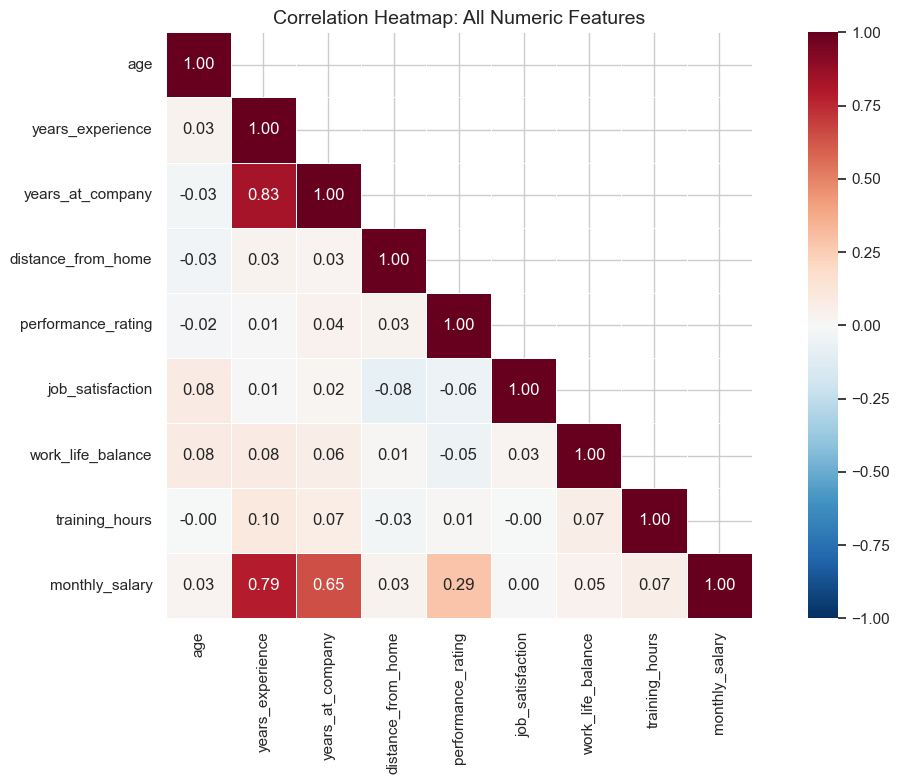

Red = positive correlation (move together)
Blue = negative correlation (move opposite)
White = no correlation


In [16]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

print("Red = positive correlation (move together)")
print("Blue = negative correlation (move opposite)")
print("White = no correlation")

In [17]:
# Grouped statistics: salary by department and attrition rate by department
print("Average Monthly Salary by Department:")
dept_stats = df.groupby("department").agg(
    avg_salary=("monthly_salary", "mean"),
    median_salary=("monthly_salary", "median"),
    count=("monthly_salary", "count"),
    attrition_rate=("attrition", lambda x: (x == "Yes").mean() * 100),
).round(1).sort_values("avg_salary", ascending=False)

print(dept_stats)
print(f"\nObservation: Engineering has the highest average salary.")
print(f"Attrition rate varies by department — worth investigating.")

Average Monthly Salary by Department:
             avg_salary  median_salary  count  attrition_rate
department                                                   
Engineering     65677.8        64560.0    175            16.0
Hr              61404.9        61080.0     91             7.7
Marketing       58832.3        58764.0     71            11.3
Sales           57249.2        58121.0    115            12.2
Support         56713.1        56881.5     48            10.4

Observation: Engineering has the highest average salary.
Attrition rate varies by department — worth investigating.


### --- PAUSE: Statistics Discussion ---

**What we learned:**

1. **Salary drivers:** `years_experience` and `performance_rating` have the strongest correlation with salary. This makes business sense.

2. **Attrition signals:** `job_satisfaction` and `work_life_balance` correlate negatively with attrition (unhappy employees leave). `distance_from_home` may push people to leave.

3. **Skewness:** Check if any features are heavily skewed — this can affect linear models.

4. **Correlation is NOT causation:** High salary doesn't *cause* people to stay — there could be confounding factors (e.g., senior roles have both high salary AND more commitment).

**Questions to ask:**
- Which features should we include in each model?
- Are any features redundant (highly correlated with each other)?
- Do we need to handle outliers?

---
# STAGE 5: Data Visualization

---

### Chart Selection Guide

| Question type | Chart | When |
|---|---|---|
| Distribution of one numeric column | **Histogram** | "What does salary look like?" |
| Spread & outliers by group | **Box plot** | "How does salary vary by department?" |
| Relationship between two numbers | **Scatter plot** | "Does experience predict salary?" |
| Counts of categories | **Count plot / Bar** | "How many employees per department?" |
| Compare averages across groups | **Bar chart** | "Average salary by education level" |

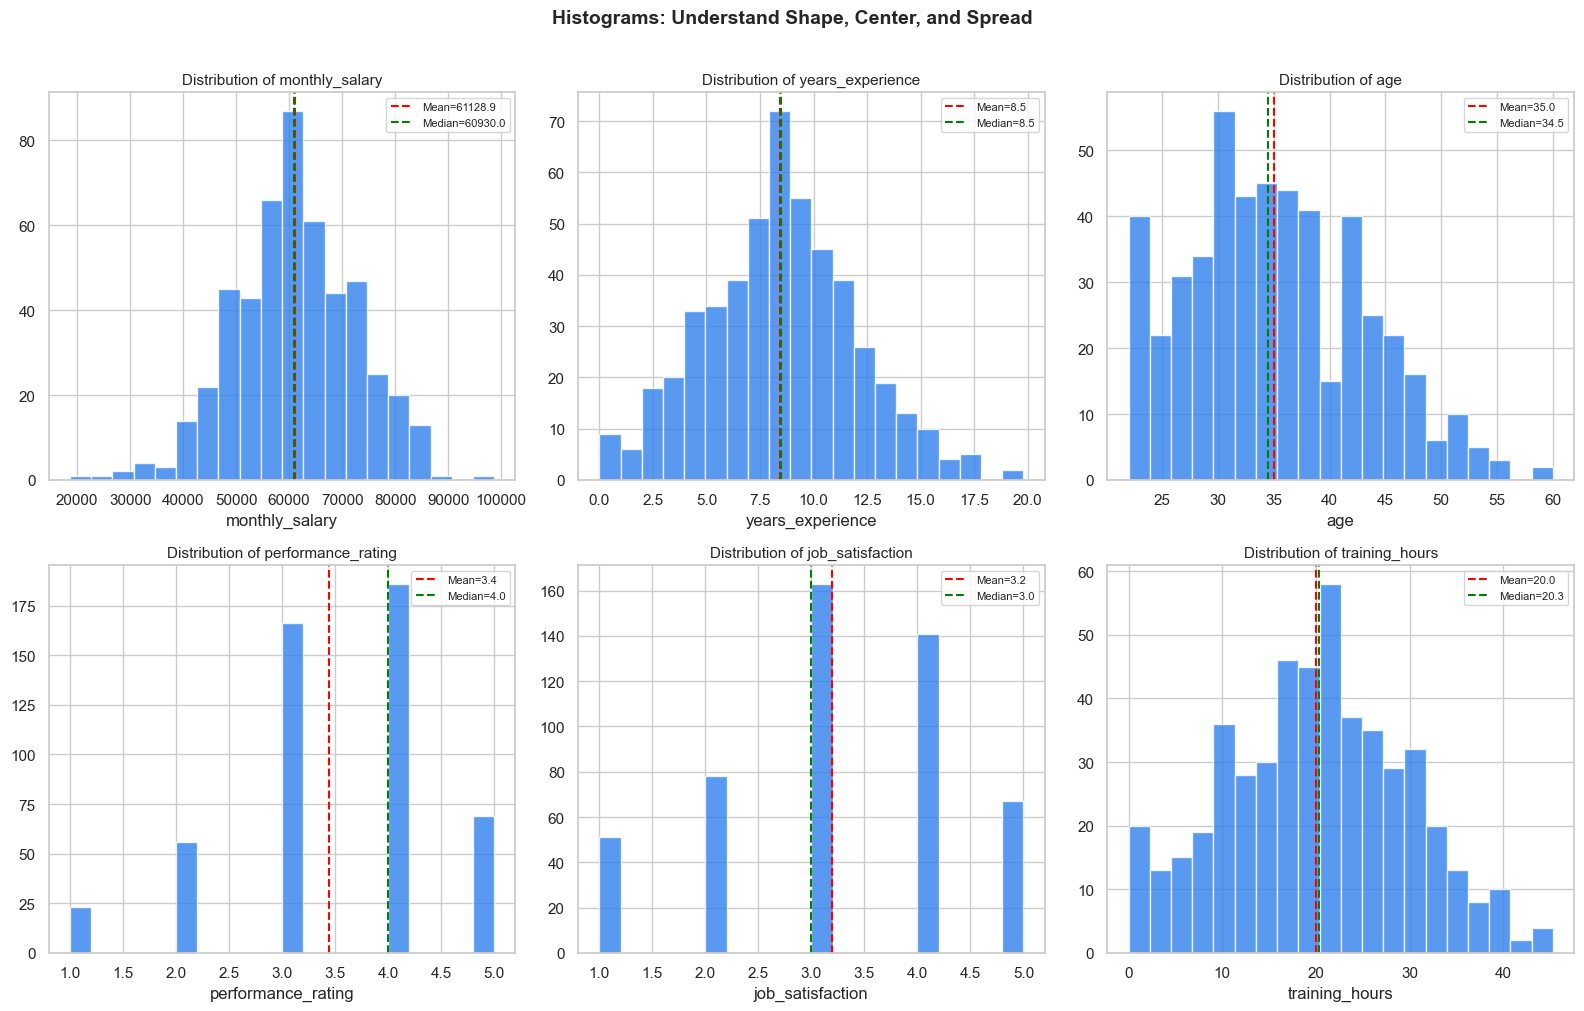

Red dashed = Mean | Green dashed = Median
When Mean and Median are close --> symmetric distribution
When Mean > Median --> right-skewed (pulled by high values)


In [18]:
# --- 5a: Distributions of key numeric features ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_cols = ["monthly_salary", "years_experience", "age",
             "performance_rating", "job_satisfaction", "training_hours"]

for ax, col in zip(axes.flat, plot_cols):
    ax.hist(df[col], bins=20, color="#2F80ED", edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="green", linestyle="--", label=f"Median={df[col].median():.1f}")
    ax.set_title(f"Distribution of {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle("Histograms: Understand Shape, Center, and Spread", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Red dashed = Mean | Green dashed = Median")
print("When Mean and Median are close --> symmetric distribution")
print("When Mean > Median --> right-skewed (pulled by high values)")

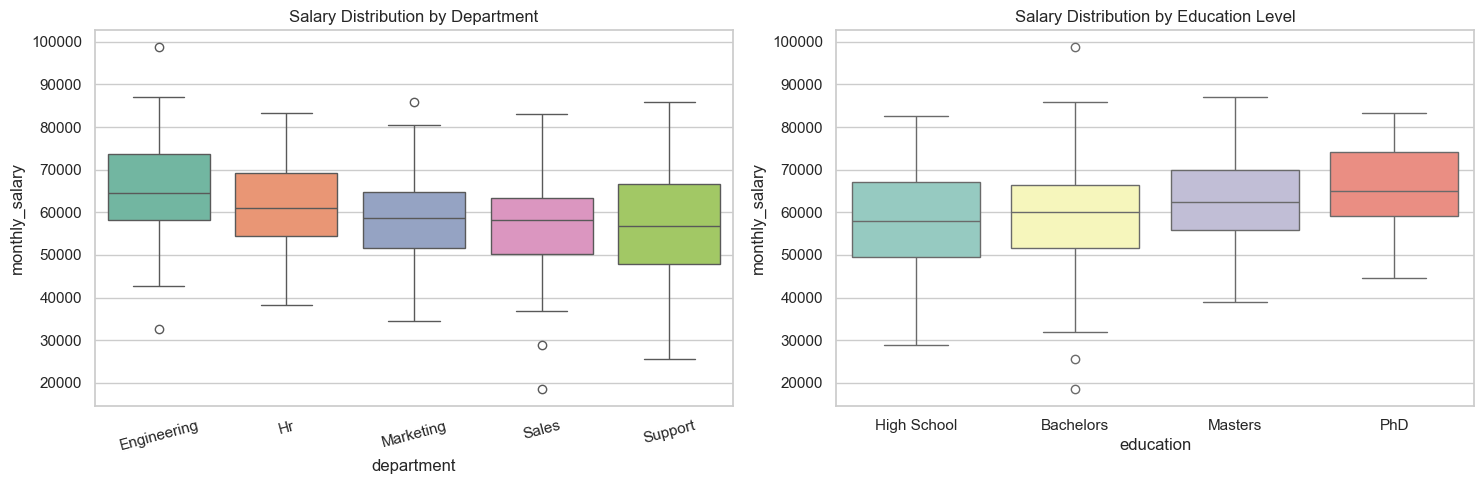

How to read a box plot:
  - Box = middle 50% (IQR: Q1 to Q3)
  - Line inside box = Median
  - Whiskers = range (excluding outliers)
  - Dots beyond whiskers = Outliers


In [19]:
# --- 5b: Box plots — Salary by Department and by Education ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_dept = df.groupby("department")["monthly_salary"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="department", y="monthly_salary", order=order_dept, ax=axes[0], palette="Set2")
axes[0].set_title("Salary Distribution by Department")
axes[0].tick_params(axis='x', rotation=15)

order_edu = ["High School", "Bachelors", "Masters", "PhD"]
sns.boxplot(data=df, x="education", y="monthly_salary", order=order_edu, ax=axes[1], palette="Set3")
axes[1].set_title("Salary Distribution by Education Level")

plt.tight_layout()
plt.show()

print("How to read a box plot:")
print("  - Box = middle 50% (IQR: Q1 to Q3)")
print("  - Line inside box = Median")
print("  - Whiskers = range (excluding outliers)")
print("  - Dots beyond whiskers = Outliers")

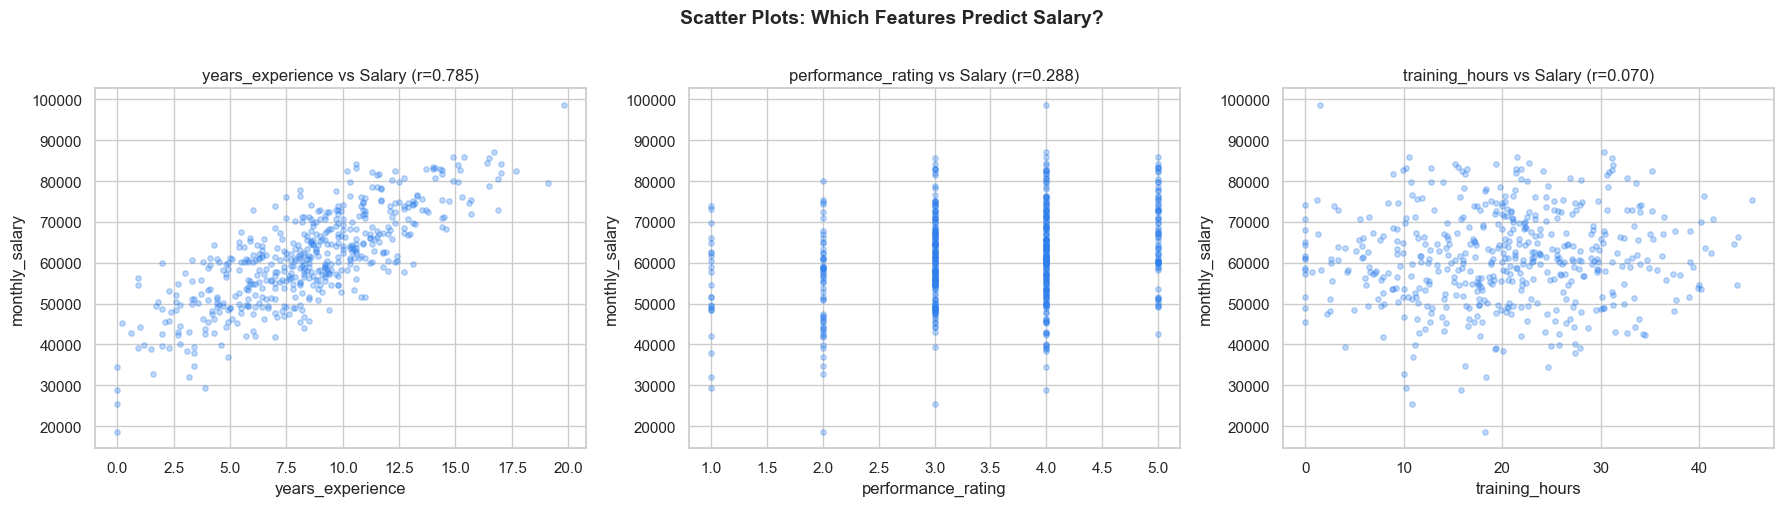

Upward cloud = positive relationship (more experience -> higher salary)
Tighter cloud = stronger relationship (better predictor)
Random cloud = weak/no relationship


In [20]:
# --- 5c: Scatter plots — Key relationships with salary ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_cols = ["years_experience", "performance_rating", "training_hours"]
for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df["monthly_salary"], alpha=0.3, s=15, color="#2F80ED")
    ax.set_xlabel(col)
    ax.set_ylabel("monthly_salary")
    r = df[col].corr(df["monthly_salary"])
    ax.set_title(f"{col} vs Salary (r={r:.3f})")

plt.suptitle("Scatter Plots: Which Features Predict Salary?", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Upward cloud = positive relationship (more experience -> higher salary)")
print("Tighter cloud = stronger relationship (better predictor)")
print("Random cloud = weak/no relationship")

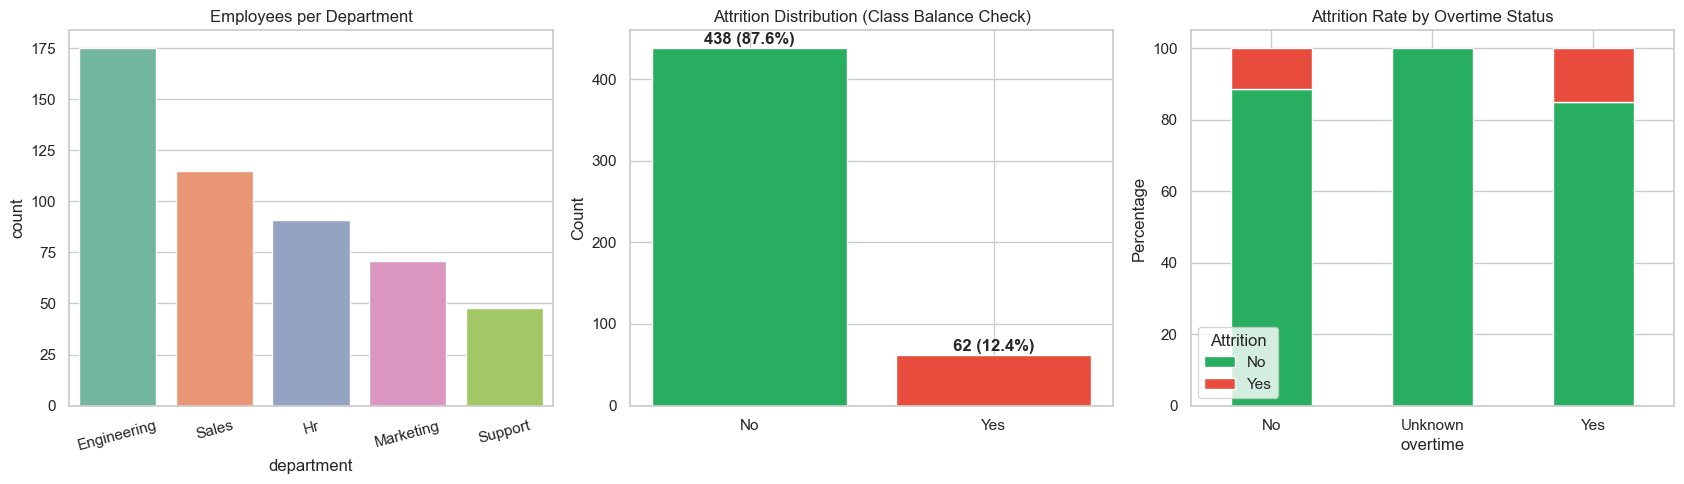

Notice the class imbalance in attrition — more 'No' than 'Yes'.
This is common in real data (most employees don't leave).
We'll need to account for this in classification evaluation.


In [21]:
# --- 5d: Count plots — Category distributions & Attrition ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Department distribution
sns.countplot(data=df, x="department", order=df["department"].value_counts().index,
              ax=axes[0], palette="Set2")
axes[0].set_title("Employees per Department")
axes[0].tick_params(axis='x', rotation=15)

# Attrition distribution (class balance check)
counts = df["attrition"].value_counts()
axes[1].bar(counts.index, counts.values, color=["#27AE60", "#E74C3C"])
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[1].text(i, val + 5, f"{val} ({val/len(df)*100:.1f}%)", ha="center", fontweight="bold")
axes[1].set_title("Attrition Distribution (Class Balance Check)")
axes[1].set_ylabel("Count")

# Attrition by overtime
ct = pd.crosstab(df["overtime"], df["attrition"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, ax=axes[2], color=["#27AE60", "#E74C3C"])
axes[2].set_title("Attrition Rate by Overtime Status")
axes[2].set_ylabel("Percentage")
axes[2].legend(title="Attrition")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Notice the class imbalance in attrition — more 'No' than 'Yes'.")
print("This is common in real data (most employees don't leave).")
print("We'll need to account for this in classification evaluation.")

### --- PAUSE: Visualization Insights ---

**What the charts tell us:**

1. **Salary distribution:** Roughly symmetric, slight right skew from senior employees
2. **Experience vs Salary:** Clear upward trend — strong predictor
3. **Performance vs Salary:** Positive but with spread — contributes but not alone
4. **Department matters:** Engineering earns more (domain premium)
5. **Education matters:** PhD > Masters > Bachelors > High School
6. **Class imbalance:** Attrition is imbalanced (~15-20% Yes) — accuracy alone will be misleading
7. **Overtime & Attrition:** Overtime employees have higher attrition rate

**Chart best practices:**
- Always title your charts with what they SHOW, not just variable names
- Include axis labels
- Sort bars for easy comparison
- Write observations: evidence + meaning + caution

---
# STAGE 6: Preprocessing (Scaling, Encoding, Feature Engineering)

---

### Why preprocessing?

ML algorithms need **numbers**. They can't understand "Engineering" or "Male".
Some algorithms also need features on the **same scale**.

| Task | What | Why |
|---|---|---|
| **Encoding** | Convert categories to numbers | ML needs numeric input |
| **Scaling** | Put numeric features on similar ranges | Some algorithms are sensitive to scale |
| **Feature engineering** | Create useful new features | Give the model better signals |

### File journey so far

```
raw data --> cleaned data --> preprocessed data (this stage)
```

### Encoding strategies

| Method | When to use | Example | Danger if wrong |
|---|---|---|---|
| **Binary (0/1)** | Exactly 2 categories | overtime: Yes=1, No=0 | N/A |
| **One-hot encoding** | No natural order among categories | department: 5 separate 0/1 columns | N/A |
| **Ordinal mapping** | Real order exists | education: HS=1, BS=2, MS=3, PhD=4 | N/A |
| **Label encoding (1,2,3...)** | Categories with NO order | **DON'T** -- model thinks HR > Sales > Engineering | Creates fake order! |

### Scaling strategies

| Method | Formula | Result | When to use |
|---|---|---|---|
| **Standard Scaling** | z = (x - mean) / std | Mean=0, Std=1 | When data is roughly normal |
| **Min-Max Scaling** | (x - min) / (max - min) | Range [0, 1] | When you need bounded values |
| **No scaling** | -- | Original values | Tree-based models (they don't need it) |

In [22]:
# =====================================================
# STEP 6a: ENCODING — Converting Categories to Numbers
# =====================================================
df_ml = df.copy()

print("BEFORE ENCODING — What the model sees:")
print(df_ml[["gender", "department", "education", "overtime", "attrition"]].head(8))
print("\nThe model CANNOT use these text columns. We must convert them to numbers.\n")
print("=" * 65)

# --- Binary encoding: 2 categories -> 0/1 ---
print("\n1. BINARY ENCODING (2 categories -> 0 or 1)")
print("-" * 45)
df_ml["gender_encoded"] = (df_ml["gender"] == "Male").astype(int)
df_ml["overtime_encoded"] = (df_ml["overtime"] == "Yes").astype(int)
df_ml["attrition_encoded"] = (df_ml["attrition"] == "Yes").astype(int)

print("  gender:    Male=1, Female=0")
print("  overtime:  Yes=1, No=0")
print("  attrition: Yes=1, No=0")

# Show before vs after
sample = df_ml[["gender", "gender_encoded", "overtime", "overtime_encoded"]].head(5)
print(f"\n  Before vs After:")
print(sample.to_string(index=False))

# --- Ordinal encoding: categories WITH natural order ---
print("\n\n2. ORDINAL ENCODING (categories with a real order)")
print("-" * 45)
edu_map = {"High School": 1, "Bachelors": 2, "Masters": 3, "PhD": 4}
df_ml["education_encoded"] = df_ml["education"].map(edu_map)

print(f"  Mapping: {edu_map}")
print(f"  Why ordinal? Because PhD > Masters > Bachelors > High School (real order exists)")
sample_edu = df_ml[["education", "education_encoded"]].drop_duplicates().sort_values("education_encoded")
print(f"\n  Before vs After:")
print(sample_edu.to_string(index=False))

# --- One-hot encoding: categories WITHOUT order ---
print("\n\n3. ONE-HOT ENCODING (categories with NO natural order)")
print("-" * 45)
print(f"  Department values: {sorted(df_ml['department'].unique())}")
print(f"\n  WHY NOT ordinal? If we code Engineering=1, HR=2, Sales=3...")
print(f"  The model thinks Sales > HR > Engineering. That's a FAKE ORDER!")
print(f"\n  One-hot encoding creates a separate 0/1 column for each category:")

dept_dummies = pd.get_dummies(df_ml["department"], prefix="dept", drop_first=True, dtype=int)
df_ml = pd.concat([df_ml, dept_dummies], axis=1)

# Show the one-hot result
print(f"  New columns: {list(dept_dummies.columns)}")
sample_ohe = pd.concat([df_ml["department"].head(8), dept_dummies.head(8)], axis=1)
print(f"\n  Before vs After:")
print(sample_ohe.to_string(index=False))

print(f"\n  drop_first=True: We dropped 'Engineering' column.")
print(f"  Why? If all other dept columns are 0, it MUST be Engineering. No info lost.")

BEFORE ENCODING — What the model sees:
   gender   department    education overtime attrition
0    Male    Marketing  High School       No       Yes
1    Male  Engineering      Masters       No        No
2    Male    Marketing    Bachelors       No        No
3  Female  Engineering      Masters       No        No
4    Male  Engineering    Bachelors       No       Yes
5    Male           Hr  High School       No        No
6  Female  Engineering      Masters      Yes        No
7    Male    Marketing  High School      Yes        No

The model CANNOT use these text columns. We must convert them to numbers.


1. BINARY ENCODING (2 categories -> 0 or 1)
---------------------------------------------
  gender:    Male=1, Female=0
  overtime:  Yes=1, No=0
  attrition: Yes=1, No=0

  Before vs After:
gender  gender_encoded overtime  overtime_encoded
  Male               1       No                 0
  Male               1       No                 0
  Male               1       No                 0

In [23]:
# =====================================================
# STEP 6b: SCALING — Putting Features on the Same Scale
# =====================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- The Problem: Features have VERY different ranges ---
scale_demo_cols = ["age", "years_experience", "monthly_salary", "performance_rating"]
print("THE PROBLEM — Features on different scales:")
print("=" * 60)
print(df_ml[scale_demo_cols].describe().loc[["min", "max", "mean", "std"]].round(1))
print("\nage: 22-60 | salary: 18K-120K | rating: 1-5")
print("Salary is ~1000x larger than rating. Some algorithms think salary")
print("is 1000x more IMPORTANT, which is wrong!")

# --- Standard Scaling ---
print("\n\n1. STANDARD SCALING (z-score normalization)")
print("-" * 50)
print("Formula: z = (x - mean) / std")
print("Result:  Mean becomes 0, Std becomes 1")
print("Reading: z = +1.5 means '1.5 standard deviations above average'")
print("         z = -0.8 means '0.8 standard deviations below average'\n")

scaler_std = StandardScaler()
demo_data = df_ml[scale_demo_cols].head(6).copy()
demo_scaled_std = pd.DataFrame(
    scaler_std.fit_transform(df_ml[scale_demo_cols]).round(3)[:6],
    columns=[f"{c}_std" for c in scale_demo_cols]
)

before_after_std = pd.concat([demo_data.reset_index(drop=True), demo_scaled_std], axis=1)
print("Before vs After (Standard Scaling):")
print(before_after_std.to_string(index=False))

print(f"\nAfter scaling — all columns now have similar ranges:")
scaled_all_std = pd.DataFrame(scaler_std.fit_transform(df_ml[scale_demo_cols]), columns=scale_demo_cols)
print(scaled_all_std.describe().loc[["min", "max", "mean", "std"]].round(2))

# --- Min-Max Scaling ---
print("\n\n2. MIN-MAX SCALING (normalization to 0-1)")
print("-" * 50)
print("Formula: x_scaled = (x - min) / (max - min)")
print("Result:  All values squeezed into [0, 1]")
print("Reading: 0.0 = minimum value, 1.0 = maximum value")
print("         0.5 = halfway between min and max\n")

scaler_mm = MinMaxScaler()
demo_scaled_mm = pd.DataFrame(
    scaler_mm.fit_transform(df_ml[scale_demo_cols]).round(3)[:6],
    columns=[f"{c}_minmax" for c in scale_demo_cols]
)

before_after_mm = pd.concat([demo_data.reset_index(drop=True), demo_scaled_mm], axis=1)
print("Before vs After (Min-Max Scaling):")
print(before_after_mm.to_string(index=False))

print(f"\nAfter scaling — all columns now between 0 and 1:")
scaled_all_mm = pd.DataFrame(scaler_mm.fit_transform(df_ml[scale_demo_cols]), columns=scale_demo_cols)
print(scaled_all_mm.describe().loc[["min", "max", "mean", "std"]].round(2))

THE PROBLEM — Features on different scales:
       age  years_experience  monthly_salary  performance_rating
min   22.0               0.0         18657.0                 1.0
max   60.0              19.8         98678.0                 5.0
mean  35.0               8.5         61128.9                 3.4
std    7.9               3.5         11435.6                 1.0

age: 22-60 | salary: 18K-120K | rating: 1-5
Salary is ~1000x larger than rating. Some algorithms think salary
is 1000x more IMPORTANT, which is wrong!


1. STANDARD SCALING (z-score normalization)
--------------------------------------------------
Formula: z = (x - mean) / std
Result:  Mean becomes 0, Std becomes 1
Reading: z = +1.5 means '1.5 standard deviations above average'
         z = -0.8 means '0.8 standard deviations below average'

Before vs After (Standard Scaling):
 age  years_experience  monthly_salary  performance_rating  age_std  years_experience_std  monthly_salary_std  performance_rating_std
49.0          

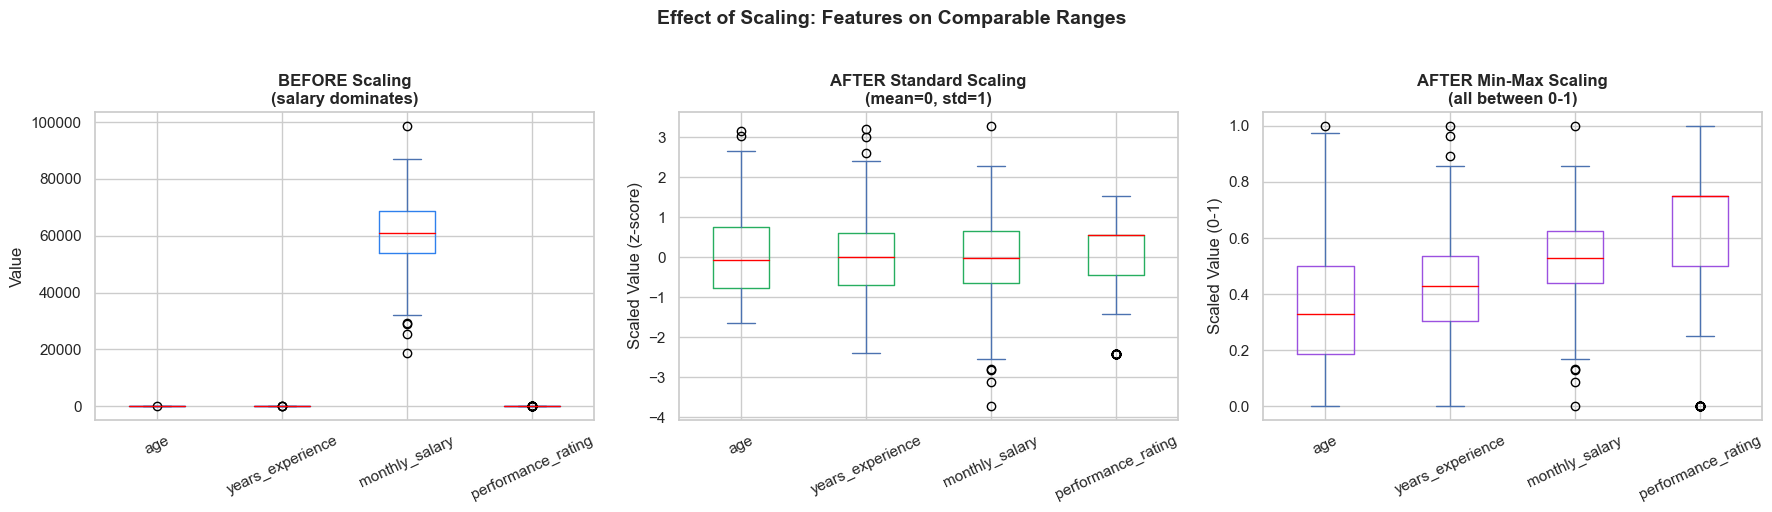

LEFT:   salary's box dwarfs everything else — rating is invisible
MIDDLE: all features on the same z-score scale — comparable spread
RIGHT:  all features squeezed into [0, 1] — comparable range


In [24]:
# =====================================================
# STEP 6c: VISUAL — Before vs After Scaling
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Before scaling
df_ml[scale_demo_cols].plot(kind="box", ax=axes[0], color=dict(boxes="#2F80ED", medians="red"))
axes[0].set_title("BEFORE Scaling\n(salary dominates)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Value")
axes[0].tick_params(axis='x', rotation=25)

# After Standard Scaling
scaled_all_std.plot(kind="box", ax=axes[1], color=dict(boxes="#27AE60", medians="red"))
axes[1].set_title("AFTER Standard Scaling\n(mean=0, std=1)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Scaled Value (z-score)")
axes[1].tick_params(axis='x', rotation=25)

# After Min-Max Scaling
scaled_all_mm.plot(kind="box", ax=axes[2], color=dict(boxes="#9B51E0", medians="red"))
axes[2].set_title("AFTER Min-Max Scaling\n(all between 0-1)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Scaled Value (0-1)")
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle("Effect of Scaling: Features on Comparable Ranges", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("LEFT:   salary's box dwarfs everything else — rating is invisible")
print("MIDDLE: all features on the same z-score scale — comparable spread")
print("RIGHT:  all features squeezed into [0, 1] — comparable range")

In [25]:
# =====================================================
# STEP 6d: fit, transform, fit_transform — AND Data Leakage
# =====================================================
print("CRITICAL CONCEPT: fit() vs transform() vs fit_transform()")
print("=" * 60)
print("""
fit():           Learn the parameters (mean, std, min, max) from data
transform():     Apply the learned parameters to transform data
fit_transform():  Do both in one step (shortcut for fit + transform)

CORRECT WORKFLOW:
  scaler.fit(X_train)           # Learn from training data ONLY
  X_train_scaled = scaler.transform(X_train)   # Transform training data
  X_test_scaled  = scaler.transform(X_test)    # Transform test with SAME parameters

WRONG (Data Leakage!):
  scaler.fit(X_test)            # NEVER fit on test data!
  scaler.fit_transform(X_test)  # NEVER! This learns from test data

WHY? If the scaler learns the mean/std from test data, the model
indirectly "sees" test data during training. This is DATA LEAKAGE.
""")

# Demo: correct vs wrong
print("DEMO: Correct Scaling Workflow")
print("-" * 45)
from sklearn.model_selection import train_test_split as tts
demo_X = df_ml[["age", "years_experience", "monthly_salary"]].values
demo_train, demo_test = tts(demo_X, test_size=0.2, random_state=42)

sc = StandardScaler()
sc.fit(demo_train)  # Learn ONLY from training data

train_scaled = sc.transform(demo_train)
test_scaled = sc.transform(demo_test)    # Use SAME parameters

print(f"Training mean (should be ~0):  {train_scaled.mean(axis=0).round(4)}")
print(f"Training std  (should be ~1):  {train_scaled.std(axis=0).round(4)}")
print(f"Test mean     (close to 0):    {test_scaled.mean(axis=0).round(4)}")
print(f"Test std      (close to 1):    {test_scaled.std(axis=0).round(4)}")
print(f"\nTest stats are CLOSE but not exactly 0/1 — that's correct!")
print(f"The scaler used training parameters, not test parameters.")

CRITICAL CONCEPT: fit() vs transform() vs fit_transform()

fit():           Learn the parameters (mean, std, min, max) from data
transform():     Apply the learned parameters to transform data
fit_transform():  Do both in one step (shortcut for fit + transform)

CORRECT WORKFLOW:
  scaler.fit(X_train)           # Learn from training data ONLY
  X_train_scaled = scaler.transform(X_train)   # Transform training data
  X_test_scaled  = scaler.transform(X_test)    # Transform test with SAME parameters

WRONG (Data Leakage!):
  scaler.fit(X_test)            # NEVER fit on test data!
  scaler.fit_transform(X_test)  # NEVER! This learns from test data

WHY? If the scaler learns the mean/std from test data, the model
indirectly "sees" test data during training. This is DATA LEAKAGE.

DEMO: Correct Scaling Workflow
---------------------------------------------
Training mean (should be ~0):  [0. 0. 0.]
Training std  (should be ~1):  [1. 1. 1.]
Test mean     (close to 0):    [-0.0523  0.0847 -0.0

In [26]:
# =====================================================
# STEP 6e: VERIFICATION — Check the Preprocessed Data
# =====================================================
print("PREPROCESSED DATA VERIFICATION")
print("=" * 60)

# Which algorithm needs what?
print("\nWHICH ALGORITHMS NEED SCALING?")
print("-" * 45)
print("""
| Algorithm               | Needs Scaling? | Why                                    |
|-------------------------|----------------|----------------------------------------|
| Linear Regression       | Helpful        | Coefficients more comparable            |
| Logistic Regression     | Yes            | Gradient descent converges faster       |
| KNN, SVM               | Yes            | Distance-based — scale matters!         |
| Decision Tree           | No             | Splits on thresholds, not distances     |
| Random Forest           | No             | Collection of trees — same reason       |
| Naive Bayes             | No             | Probability-based, not distance-based   |
| Neural Networks         | Yes            | Gradient descent, weight initialization |
""")

print("For THIS notebook: we use trees + forest + Naive Bayes -> NO scaling needed.")
print("We showed scaling for LEARNING — you'll need it for other algorithms.\n")

# Final preprocessed column check
encoded_cols = [c for c in df_ml.columns if c.endswith("_encoded") or c.startswith("dept_")]
print(f"Original text columns: gender, department, education, overtime, attrition")
print(f"Encoded columns:       {encoded_cols}")
print(f"\nTotal columns: {df_ml.shape[1]} (original + encoded)")
print(f"Rows: {df_ml.shape[0]}")
print(f"Missing: {df_ml.isna().sum().sum()}")
print(f"\nPreprocessing complete. Ready for ML!")

PREPROCESSED DATA VERIFICATION

WHICH ALGORITHMS NEED SCALING?
---------------------------------------------

| Algorithm               | Needs Scaling? | Why                                    |
|-------------------------|----------------|----------------------------------------|
| Linear Regression       | Helpful        | Coefficients more comparable            |
| Logistic Regression     | Yes            | Gradient descent converges faster       |
| KNN, SVM               | Yes            | Distance-based — scale matters!         |
| Decision Tree           | No             | Splits on thresholds, not distances     |
| Random Forest           | No             | Collection of trees — same reason       |
| Naive Bayes             | No             | Probability-based, not distance-based   |
| Neural Networks         | Yes            | Gradient descent, weight initialization |

For THIS notebook: we use trees + forest + Naive Bayes -> NO scaling needed.
We showed scaling for LEARNING —

### --- PAUSE: Preprocessing — Complete Summary ---

**ENCODING — What we did and WHY:**

| Column | Method | Why this method |
|---|---|---|
| gender (Male/Female) | Binary (0/1) | Only 2 categories |
| overtime (Yes/No) | Binary (0/1) | Only 2 categories |
| attrition (Yes/No) | Binary (0/1) | Only 2 categories (this is our target) |
| education (HS/BS/MS/PhD) | Ordinal (1/2/3/4) | Real order exists: PhD > Masters > Bachelors > HS |
| department (5 values) | One-hot encoding | NO natural order — one-hot avoids fake ordering |

**Common mistake: Why not just number every category?**
If we encode department as Engineering=1, HR=2, Marketing=3, Sales=4, Support=5:
- The model thinks Support(5) > Sales(4) > Marketing(3)
- It might calculate "average department = 3" (Marketing?) — meaningless!
- One-hot encoding prevents this by creating separate 0/1 columns

**SCALING — What we learned:**

| | Standard Scaling | Min-Max Scaling |
|---|---|---|
| Formula | (x - mean) / std | (x - min) / (max - min) |
| Output range | ~[-3, +3] (no fixed bounds) | [0, 1] (fixed bounds) |
| Center | Mean = 0 | Min = 0, Max = 1 |
| Sensitive to outliers? | Less (uses std) | More (uses min/max) |
| When to use | Most cases, normal-ish data | When you need bounded [0,1] values |

**DATA LEAKAGE — The #1 preprocessing mistake:**
- `fit()` on training data ONLY
- `transform()` on both train and test
- NEVER `fit()` or `fit_transform()` on test data
- Think of it like: the teacher (scaler) learns from practice problems (train), then grades the exam (test) using the same rules

**When is scaling needed?**
- Distance-based algorithms (KNN, SVM): YES
- Gradient-based algorithms (Linear/Logistic Regression, Neural Nets): YES
- Tree-based algorithms (Decision Tree, Random Forest): NO — they split on thresholds

**File journey:** `raw data` -> `cleaned data` -> `preprocessed data` -> ready for ML!

---
# STAGE 7: ML Foundations — Features, Target, Train-Test Split

---

### Features (X) vs Target (y)

| Term | Role | Also called |
|---|---|---|
| **Features (X)** | Input columns — what we use to predict | Independent variables, predictors |
| **Target (y)** | Output column — what we want to predict | Dependent variable, label |

### What NOT to include as features

| Column | Include? | Reason |
|---|---|---|
| emp_id | No | Just an identifier |
| name | No | Not predictive |
| monthly_salary | No (for attrition model) | Could cause data leakage |
| attrition | No (for salary model) | It's the other target |
| Original text columns | No | Already encoded |

### Train-Test Split

```
Full Data (500 rows)
  |--- Training Set (80% = 400 rows) --> Model learns from this
  |--- Test Set (20% = 100 rows)      --> Model evaluated here (NEVER seen during training)
```

**Why?** To measure how well the model generalizes to NEW, unseen data.
Without this, we'd be measuring memorization, not learning.

In [27]:
from sklearn.model_selection import train_test_split

# ---- REGRESSION: Predict monthly_salary ----
reg_features = ["age", "years_experience", "years_at_company", "distance_from_home",
                "performance_rating", "job_satisfaction", "work_life_balance",
                "training_hours", "gender_encoded", "overtime_encoded",
                "education_encoded"] + list(dept_dummies.columns)

X_reg = df_ml[reg_features]
y_reg = df_ml["monthly_salary"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("REGRESSION SETUP: Predicting monthly_salary")
print(f"  Features ({len(reg_features)}): {reg_features}")
print(f"  Training: {X_reg_train.shape[0]} rows | Test: {X_reg_test.shape[0]} rows")
print(f"  Target range: {y_reg.min():.0f} to {y_reg.max():.0f}")
print(f"  Train mean: {y_reg_train.mean():.0f} | Test mean: {y_reg_test.mean():.0f}  (similar = good split)")

REGRESSION SETUP: Predicting monthly_salary
  Features (15): ['age', 'years_experience', 'years_at_company', 'distance_from_home', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'training_hours', 'gender_encoded', 'overtime_encoded', 'education_encoded', 'dept_Hr', 'dept_Marketing', 'dept_Sales', 'dept_Support']
  Training: 400 rows | Test: 100 rows
  Target range: 18657 to 98678
  Train mean: 61356 | Test mean: 60221  (similar = good split)


In [28]:
# ---- CLASSIFICATION: Predict attrition ----
clf_features = ["age", "years_experience", "years_at_company", "distance_from_home",
                "performance_rating", "job_satisfaction", "work_life_balance",
                "training_hours", "gender_encoded", "overtime_encoded",
                "education_encoded"] + list(dept_dummies.columns)

X_clf = df_ml[clf_features]
y_clf = df_ml["attrition_encoded"]  # 1=Yes, 0=No

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("\nCLASSIFICATION SETUP: Predicting attrition (Yes=1, No=0)")
print(f"  Features ({len(clf_features)}): {clf_features}")
print(f"  Training: {X_clf_train.shape[0]} rows | Test: {X_clf_test.shape[0]} rows")
print(f"\n  Class distribution (full data):")
print(f"    No  (0): {(y_clf == 0).sum()} ({(y_clf == 0).mean()*100:.1f}%)")
print(f"    Yes (1): {(y_clf == 1).sum()} ({(y_clf == 1).mean()*100:.1f}%)")
print(f"\n  stratify=y_clf ensures train and test have the SAME class proportions.")


CLASSIFICATION SETUP: Predicting attrition (Yes=1, No=0)
  Features (15): ['age', 'years_experience', 'years_at_company', 'distance_from_home', 'performance_rating', 'job_satisfaction', 'work_life_balance', 'training_hours', 'gender_encoded', 'overtime_encoded', 'education_encoded', 'dept_Hr', 'dept_Marketing', 'dept_Sales', 'dept_Support']
  Training: 400 rows | Test: 100 rows

  Class distribution (full data):
    No  (0): 438 (87.6%)
    Yes (1): 62 (12.4%)

  stratify=y_clf ensures train and test have the SAME class proportions.


### --- PAUSE: ML Setup Discussion ---

**Two models, one dataset:**

| | Regression | Classification |
|---|---|---|
| **Target** | monthly_salary (number) | attrition (Yes/No) |
| **Question** | "How much?" | "Which category?" |
| **Same features** | Yes | Yes |
| **Split** | 80/20 random | 80/20 stratified |

**Why stratify for classification?**
If attrition is 15% overall, a random split might give us 20% in train and 5% in test by chance. `stratify=y` ensures both sets have ~15%. This is especially important for imbalanced classes.

**Data leakage check:**
- We did NOT include `attrition` as a feature for salary prediction
- We did NOT include `monthly_salary` as a feature for attrition prediction
- We split BEFORE any model training

---
# STAGE 8: Regression — Predicting Monthly Salary

---

### The ML Flow

```
1. Choose algorithm
2. Create model object
3. Train (fit) on training data
4. Predict on test data
5. Evaluate predictions
```

We'll build THREE regression models and compare:

| Model | Idea | Strengths |
|---|---|---|
| **Linear Regression** | Fit a line/plane through data | Simple, interpretable coefficients |
| **Decision Tree** | Split data with if-else rules | Captures non-linear patterns |
| **Random Forest** | Average many trees | Stable, reduces overfitting |

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# Model 1: Linear Regression
# ==============================
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)
print("\nIdea: y = w1*x1 + w2*x2 + ... + b")
print("Each feature gets a weight (coefficient) showing its impact.\n")

lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)
y_pred_lr = lr.predict(X_reg_test)

# Show coefficients
coef_df = pd.DataFrame({
    "feature": reg_features,
    "coefficient": lr.coef_.round(2)
}).sort_values("coefficient", key=abs, ascending=False)

print(f"Intercept: {lr.intercept_:.2f}")
print(f"\nTop coefficients (what drives salary):")
for _, row in coef_df.head(8).iterrows():
    direction = "increases" if row["coefficient"] > 0 else "decreases"
    print(f"  {row['feature']:25s}  {row['coefficient']:+10.2f}  "
          f"(+1 unit {direction} salary by ${abs(row['coefficient']):.0f})")

MODEL 1: LINEAR REGRESSION

Idea: y = w1*x1 + w2*x2 + ... + b
Each feature gets a weight (coefficient) showing its impact.

Intercept: 26571.98

Top coefficients (what drives salary):
  dept_Marketing               -7849.29  (+1 unit decreases salary by $7849)
  dept_Sales                   -7316.51  (+1 unit decreases salary by $7317)
  dept_Support                 -7273.65  (+1 unit decreases salary by $7274)
  dept_Hr                      -7272.30  (+1 unit decreases salary by $7272)
  performance_rating           +2974.96  (+1 unit increases salary by $2975)
  years_experience             +2530.11  (+1 unit increases salary by $2530)
  education_encoded            +2324.76  (+1 unit increases salary by $2325)
  gender_encoded                -549.97  (+1 unit decreases salary by $550)


In [30]:
# ==============================
# Model 2: Decision Tree Regression
# ==============================
print("=" * 60)
print("MODEL 2: DECISION TREE REGRESSION")
print("=" * 60)
print("\nIdea: Split data into regions using if-else rules.")
print("Each leaf predicts the average salary of its region.\n")

dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_reg_train, y_reg_train)
y_pred_dt = dt_reg.predict(X_reg_test)

print(f"Tree depth: {dt_reg.get_depth()}")
print(f"Number of leaves: {dt_reg.get_n_leaves()}")

# Feature importance
dt_imp = pd.DataFrame({
    "feature": reg_features,
    "importance": dt_reg.feature_importances_.round(4)
}).sort_values("importance", ascending=False)

print(f"\nFeature importance (what the tree used for splitting):")
for _, row in dt_imp[dt_imp["importance"] > 0.01].iterrows():
    bar = "#" * int(row["importance"] * 40)
    print(f"  {row['feature']:25s}  {row['importance']:.4f}  {bar}")

MODEL 2: DECISION TREE REGRESSION

Idea: Split data into regions using if-else rules.
Each leaf predicts the average salary of its region.



Tree depth: 5
Number of leaves: 29

Feature importance (what the tree used for splitting):
  years_experience           0.8514  ##################################
  performance_rating         0.0577  ##
  education_encoded          0.0224  
  dept_Sales                 0.0176  
  dept_Hr                    0.0173  
  training_hours             0.0157  


In [31]:
# ==============================
# Model 3: Random Forest Regression
# ==============================
print("=" * 60)
print("MODEL 3: RANDOM FOREST REGRESSION")
print("=" * 60)
print("\nIdea: Build 100 decision trees on random subsets, average their predictions.")
print("Individual trees overfit differently; averaging cancels out errors.\n")

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_reg.fit(X_reg_train, y_reg_train)
y_pred_rf = rf_reg.predict(X_reg_test)

print(f"Number of trees: {rf_reg.n_estimators}")
print(f"Max depth per tree: {rf_reg.max_depth}")

# Feature importance
rf_imp = pd.DataFrame({
    "feature": reg_features,
    "importance": rf_reg.feature_importances_.round(4)
}).sort_values("importance", ascending=False)

print(f"\nFeature importance (averaged across 100 trees — more stable):")
for _, row in rf_imp[rf_imp["importance"] > 0.01].iterrows():
    bar = "#" * int(row["importance"] * 40)
    print(f"  {row['feature']:25s}  {row['importance']:.4f}  {bar}")

MODEL 3: RANDOM FOREST REGRESSION

Idea: Build 100 decision trees on random subsets, average their predictions.
Individual trees overfit differently; averaging cancels out errors.



Number of trees: 100
Max depth per tree: 8

Feature importance (averaged across 100 trees — more stable):
  years_experience           0.6974  ###########################
  performance_rating         0.0638  ##
  training_hours             0.0401  #
  education_encoded          0.0318  #
  age                        0.0309  #
  years_at_company           0.0296  #
  distance_from_home         0.0276  #
  dept_Sales                 0.0169  
  job_satisfaction           0.0137  
  work_life_balance          0.0118  
  dept_Hr                    0.0113  


### --- PAUSE: Regression Models Discussion ---

**Three different approaches to the same problem:**

| Model | How it works | Interpretability |
|---|---|---|
| **Linear Regression** | Draws a plane through data; coefficients tell exact impact | Very high — "+1 year experience = +$X salary" |
| **Decision Tree** | Creates if-else rules; splits at best thresholds | High — you can follow the tree |
| **Random Forest** | Averages 100 trees; each sees random subset | Medium — feature importance, but no single tree to follow |

**Feature importance comparison:**
- All three models agree that `years_experience` and `performance_rating` are top predictors
- This consistency across different algorithms increases our confidence

**The scikit-learn pattern (same for ALL models):**
```python
model = SomeRegressor()      # Create
model.fit(X_train, y_train)  # Train
y_pred = model.predict(X_test)  # Predict
```

**Next: How do we decide which model is BEST? We need evaluation metrics.**

---
# STAGE 9: Regression Evaluation Metrics

---

### Building intuition: What is error?

```
Error = Actual - Predicted
```

| Metric | Formula | Intuition | Units |
|---|---|---|---|
| **MAE** | mean(\|error\|) | Average mistake size | Same as target ($) |
| **MSE** | mean(error^2) | Penalizes big mistakes heavily | Squared ($^2) |
| **RMSE** | sqrt(MSE) | MAE's big-mistake-aware cousin | Same as target ($) |
| **R-squared** | 1 - (model_error / baseline_error) | How much better than guessing the mean? | 0 to 1 (unitless) |

**When RMSE >> MAE:** The model has some very large errors (outlier predictions).

In [32]:
# ---- Step-by-step metric calculation (for understanding) ----
print("Manual Metric Calculation (first 5 test samples, Linear Regression):")
print(f"{'Actual':>10s} {'Predicted':>10s} {'Error':>10s} {'|Error|':>10s} {'Error^2':>12s}")
print("-" * 55)

for i in range(5):
    actual = y_reg_test.values[i]
    pred = y_pred_lr[i]
    error = actual - pred
    print(f"{actual:10.0f} {pred:10.0f} {error:10.0f} {abs(error):10.0f} {error**2:12.0f}")

errors = y_reg_test.values - y_pred_lr
print(f"\nMAE  = mean(|errors|) = ${np.abs(errors).mean():,.0f}")
print(f"MSE  = mean(errors^2) = {(errors**2).mean():,.0f}")
print(f"RMSE = sqrt(MSE)      = ${np.sqrt((errors**2).mean()):,.0f}")
print(f"R^2  = 1 - (sum(errors^2) / sum((actual-mean)^2)) = {r2_score(y_reg_test, y_pred_lr):.4f}")

Manual Metric Calculation (first 5 test samples, Linear Regression):
    Actual  Predicted      Error    |Error|      Error^2
-------------------------------------------------------
     49014      52407      -3393       3393     11513643
     66557      69075      -2518       2518      6338391
     59865      64026      -4161       4161     17311847
     75157      62721      12436      12436    154651273
     64020      65981      -1961       1961      3846709

MAE  = mean(|errors|) = $4,195
MSE  = mean(errors^2) = 25,502,119
RMSE = sqrt(MSE)      = $5,050
R^2  = 1 - (sum(errors^2) / sum((actual-mean)^2)) = 0.8115


In [33]:
# ---- Compare all 3 regression models ----
def eval_regression(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)": round(mean_absolute_error(y_true, y_pred), 0),
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
        "R-squared": round(r2_score(y_true, y_pred), 4),
    }

reg_results = pd.DataFrame([
    eval_regression("Linear Regression", y_reg_test, y_pred_lr),
    eval_regression("Decision Tree", y_reg_test, y_pred_dt),
    eval_regression("Random Forest", y_reg_test, y_pred_rf),
])

print("REGRESSION MODEL COMPARISON")
print("=" * 65)
print(reg_results.to_string(index=False))
print("=" * 65)
print(f"\nBest R-squared: {reg_results.loc[reg_results['R-squared'].idxmax(), 'Model']}")
print(f"Lowest MAE:     {reg_results.loc[reg_results['MAE ($)'].idxmin(), 'Model']}")

REGRESSION MODEL COMPARISON
            Model  MAE ($)  RMSE ($)  R-squared
Linear Regression   4195.0    5050.0     0.8115
    Decision Tree   6255.0    7599.0     0.5732
    Random Forest   5136.0    6272.0     0.7092

Best R-squared: Linear Regression
Lowest MAE:     Linear Regression


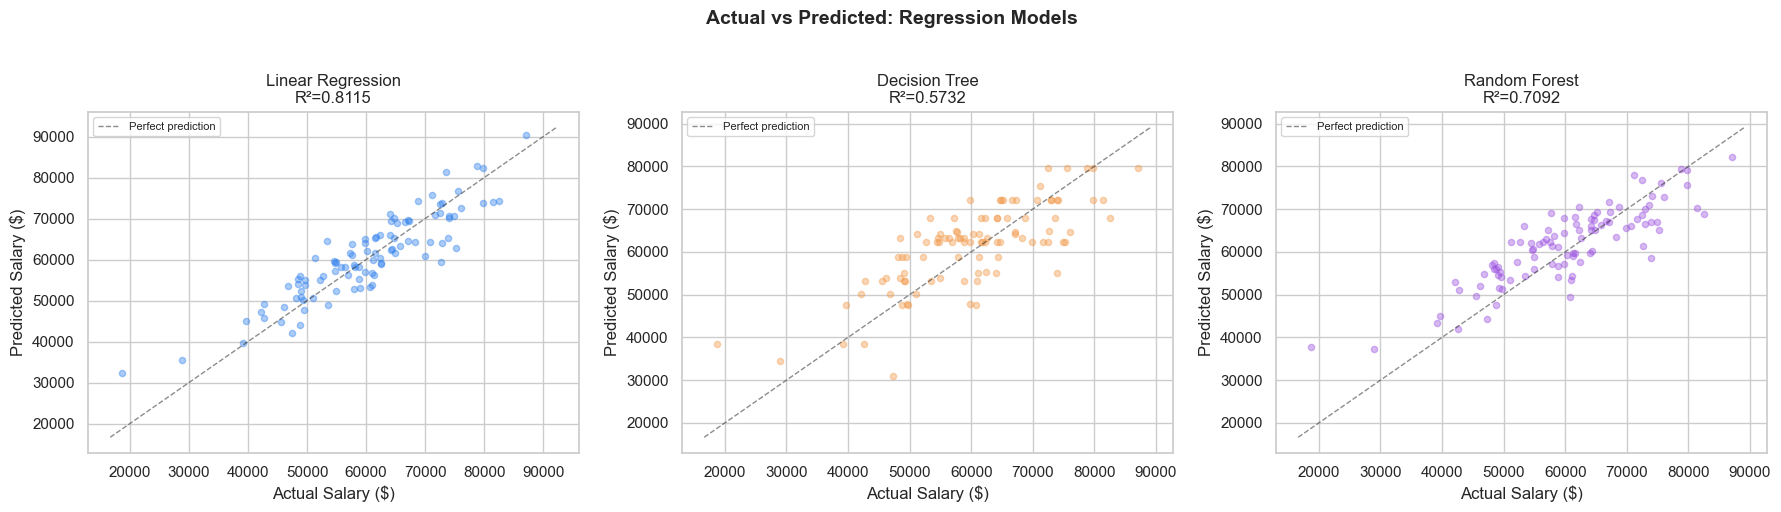

Points on the dashed line = perfect predictions.
Tighter cluster around the line = better model.


In [34]:
# ---- Visual comparison ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_reg = ["#2F80ED", "#F2994A", "#9B51E0"]
names_reg = ["Linear Regression", "Decision Tree", "Random Forest"]
preds_reg = [y_pred_lr, y_pred_dt, y_pred_rf]

for ax, name, y_pred, color in zip(axes, names_reg, preds_reg, colors_reg):
    ax.scatter(y_reg_test, y_pred, alpha=0.4, color=color, s=20)
    min_v = min(y_reg_test.min(), y_pred.min()) - 2000
    max_v = max(y_reg_test.max(), y_pred.max()) + 2000
    ax.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1, alpha=0.5, label="Perfect prediction")
    ax.set_xlabel("Actual Salary ($)")
    ax.set_ylabel("Predicted Salary ($)")
    r2 = r2_score(y_reg_test, y_pred)
    ax.set_title(f"{name}\nR²={r2:.4f}")
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted: Regression Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Points on the dashed line = perfect predictions.")
print("Tighter cluster around the line = better model.")

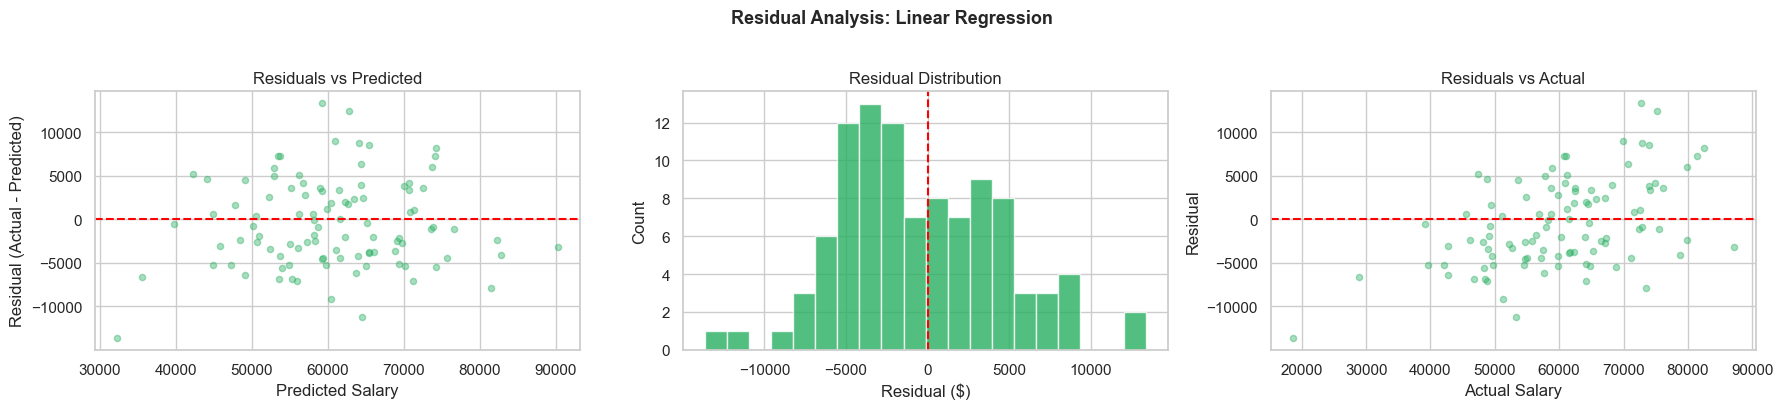

Mean residual:  $-488 (should be ~$0)
Std residual:   $5,026

Good residuals: centered at 0, no pattern, roughly symmetric.


In [35]:
# ---- Residual analysis for the best regression model ----
best_reg_idx = reg_results["R-squared"].idxmax()
best_reg_name = reg_results.loc[best_reg_idx, "Model"]
best_reg_preds = preds_reg[best_reg_idx]
best_reg_residuals = y_reg_test.values - best_reg_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residuals vs Predicted
axes[0].scatter(best_reg_preds, best_reg_residuals, alpha=0.4, color="#27AE60", s=20)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(best_reg_residuals, bins=20, color="#27AE60", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# Actual vs Residual
axes[2].scatter(y_reg_test, best_reg_residuals, alpha=0.4, color="#27AE60", s=20)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Actual Salary")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs Actual")

plt.suptitle(f"Residual Analysis: {best_reg_name}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean residual:  ${best_reg_residuals.mean():,.0f} (should be ~$0)")
print(f"Std residual:   ${best_reg_residuals.std():,.0f}")
print(f"\nGood residuals: centered at 0, no pattern, roughly symmetric.")

### --- PAUSE: Regression Evaluation Discussion ---

**How to read the results:**

| Metric | What it tells you | How to report |
|---|---|---|
| MAE = $X | "On average, predictions are off by $X" | Best for business audience |
| RMSE = $Y | "Typical error is $Y, but penalizes big mistakes more" | Technical audience |
| R² = 0.XX | "Model explains XX% of salary variation" | Quick comparison metric |

**Residual checks:**
- Centered at 0? -> Model isn't systematically over/under-predicting
- No pattern? -> Model isn't missing a relationship
- Symmetric? -> Errors are balanced

**If RMSE >> MAE:** A few predictions have very large errors (investigate those cases).

**Model selection:** Don't just pick the highest R² blindly. Consider:
- Is the improvement meaningful for the business?
- Is the simpler model close enough? (prefer simpler if similar performance)
- Does the model overfit? (check train vs test gap — coming in Stage 12)

---
# STAGE 10: Classification — Predicting Attrition

---

### Regression vs Classification

| | Regression | Classification |
|---|---|---|
| **Target** | Number (salary) | Category (Yes/No) |
| **Question** | "How much?" | "Which class?" |
| **Output** | 45000.50 | 0 (No) or 1 (Yes) |
| **Metrics** | MAE, RMSE, R² | Accuracy, Precision, Recall, F1 |

### Binary vs Multi-class

| Type | Classes | Example |
|---|---|---|
| **Binary** | 2 classes | Attrition: Yes/No |
| **Multi-class** | 3+ classes | Department: Eng/Sales/HR/... |

Our problem: **Binary classification** (Attrition: Yes or No)

### Three classification algorithms

| Model | Idea |
|---|---|
| **Naive Bayes** | Uses probability (Bayes' theorem) — assumes features are independent |
| **Decision Tree** | Splits with if-else rules, predicts majority class in each leaf |
| **Random Forest** | 100 trees vote; majority vote wins |

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# ==============================
# Model 1: Naive Bayes
# ==============================
print("=" * 60)
print("MODEL 1: GAUSSIAN NAIVE BAYES")
print("=" * 60)
print("\nIdea: For each class, calculate probability based on feature values.")
print("'Naive' = assumes all features are independent of each other.")
print("Fast, simple, works surprisingly well for many problems.\n")

nb = GaussianNB()
nb.fit(X_clf_train, y_clf_train)
y_pred_nb = nb.predict(X_clf_test)
y_prob_nb = nb.predict_proba(X_clf_test)[:, 1]  # probability of class 1 (Yes)

print(f"Training complete.")
print(f"Predictions: {(y_pred_nb == 0).sum()} predicted No, {(y_pred_nb == 1).sum()} predicted Yes")

MODEL 1: GAUSSIAN NAIVE BAYES

Idea: For each class, calculate probability based on feature values.
'Naive' = assumes all features are independent of each other.
Fast, simple, works surprisingly well for many problems.

Training complete.
Predictions: 100 predicted No, 0 predicted Yes


In [37]:
# ==============================
# Model 2: Decision Tree Classifier
# ==============================
print("=" * 60)
print("MODEL 2: DECISION TREE CLASSIFIER")
print("=" * 60)
print("\nIdea: Ask yes/no questions about features to split into classes.")
print("Each leaf contains a class prediction (Yes or No).\n")

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_clf_train, y_clf_train)
y_pred_dt_clf = dt_clf.predict(X_clf_test)
y_prob_dt_clf = dt_clf.predict_proba(X_clf_test)[:, 1]

print(f"Tree depth: {dt_clf.get_depth()}, Leaves: {dt_clf.get_n_leaves()}")

# Feature importance
dt_clf_imp = pd.DataFrame({
    "feature": clf_features,
    "importance": dt_clf.feature_importances_.round(4)
}).sort_values("importance", ascending=False)

print(f"\nTop features for predicting attrition:")
for _, row in dt_clf_imp[dt_clf_imp["importance"] > 0.02].iterrows():
    print(f"  {row['feature']:25s}  {row['importance']:.4f}")

MODEL 2: DECISION TREE CLASSIFIER

Idea: Ask yes/no questions about features to split into classes.
Each leaf contains a class prediction (Yes or No).

Tree depth: 5, Leaves: 13

Top features for predicting attrition:
  distance_from_home         0.2610
  training_hours             0.2397
  age                        0.1703
  years_at_company           0.1312
  years_experience           0.0816
  performance_rating         0.0740
  job_satisfaction           0.0421


In [38]:
# ==============================
# Model 3: Random Forest Classifier
# ==============================
print("=" * 60)
print("MODEL 3: RANDOM FOREST CLASSIFIER")
print("=" * 60)
print("\nIdea: 100 decision trees each vote. Majority wins.")
print("Like asking 100 doctors instead of 1 — more reliable.\n")

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_clf.fit(X_clf_train, y_clf_train)
y_pred_rf_clf = rf_clf.predict(X_clf_test)
y_prob_rf_clf = rf_clf.predict_proba(X_clf_test)[:, 1]

print(f"Number of trees: {rf_clf.n_estimators}")

# Feature importance
rf_clf_imp = pd.DataFrame({
    "feature": clf_features,
    "importance": rf_clf.feature_importances_.round(4)
}).sort_values("importance", ascending=False)

print(f"\nTop features for predicting attrition (Random Forest):")
for _, row in rf_clf_imp[rf_clf_imp["importance"] > 0.02].iterrows():
    print(f"  {row['feature']:25s}  {row['importance']:.4f}")

MODEL 3: RANDOM FOREST CLASSIFIER

Idea: 100 decision trees each vote. Majority wins.
Like asking 100 doctors instead of 1 — more reliable.



Number of trees: 100

Top features for predicting attrition (Random Forest):
  distance_from_home         0.1643
  training_hours             0.1320
  years_experience           0.1286
  age                        0.1223
  years_at_company           0.1219
  performance_rating         0.0787
  job_satisfaction           0.0565
  work_life_balance          0.0547
  education_encoded          0.0524
  overtime_encoded           0.0208


### --- PAUSE: Classification Models Discussion ---

**Three classifiers, same data:**

| Model | How it decides | Speed | Interpretability |
|---|---|---|---|
| **Naive Bayes** | Calculates probability using Bayes' theorem | Very fast | Moderate (probabilities) |
| **Decision Tree** | Follows if-else rules down a tree | Fast | High (you can read the rules) |
| **Random Forest** | 100 trees vote; majority wins | Slower | Medium (feature importance) |

**Notice:** Classification models output:
- `predict()` -> class label (0 or 1)
- `predict_proba()` -> probability of each class (e.g., 0.73 = 73% chance of leaving)

The probability is often MORE useful than the label — HR can prioritize employees with >60% attrition probability.

**Next: How do we evaluate classification? It's very different from regression.**

---
# STAGE 11: Classification Evaluation Metrics

---

### Why accuracy is NOT enough

If 85% of employees don't leave, a model that ALWAYS predicts "No" gets 85% accuracy. But it catches ZERO leavers — completely useless!

This is the **Accuracy Paradox** with imbalanced data.

### The Confusion Matrix

```
                    Predicted
                    No      Yes
Actual  No    [  TN    |   FP  ]    TN = Correctly predicted No
        Yes   [  FN    |   TP  ]    TP = Correctly predicted Yes
                                     FP = False alarm (predicted Yes, actually No)
                                     FN = Missed (predicted No, actually Yes)
```

### Metrics from the Confusion Matrix

| Metric | Formula | Question it answers |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Overall, how often is it correct? |
| **Precision** | TP / (TP+FP) | Of those predicted Yes, how many actually left? |
| **Recall** | TP / (TP+FN) | Of those who actually left, how many did we catch? |
| **F1 Score** | 2 * (P*R)/(P+R) | Balance between Precision and Recall |
| **ROC-AUC** | Area under ROC curve | Overall ability to distinguish classes |

### When to prioritize which metric?

| Scenario | Prioritize | Why |
|---|---|---|
| Fraud detection | **Recall** | Missing fraud is costly |
| Spam filter | **Precision** | Blocking real email is costly |
| Employee attrition | **Recall** | Missing a leaver is costly |
| Medical diagnosis | **Recall** | Missing a disease is dangerous |

In [39]:
# ---- Confusion Matrix — visual explanation ----
print("CONFUSION MATRIX — Step by Step (Naive Bayes)")
print("=" * 50)

cm = confusion_matrix(y_clf_test, y_pred_nb)
tn, fp, fn, tp = cm.ravel()

print(f"\n                 Predicted")
print(f"               No      Yes")
print(f"Actual No   [ {tn:3d}    | {fp:3d}  ]   TN={tn}, FP={fp}")
print(f"       Yes  [ {fn:3d}    | {tp:3d}  ]   FN={fn}, TP={tp}")

print(f"\nReading the matrix:")
print(f"  TN={tn}: Correctly predicted {tn} employees would STAY")
print(f"  TP={tp}: Correctly predicted {tp} employees would LEAVE")
print(f"  FP={fp}: Falsely predicted {fp} employees would leave (they stayed) — false alarm")
print(f"  FN={fn}: MISSED {fn} employees who left (predicted they'd stay) — dangerous!")

print(f"\nMetric calculation:")
print(f"  Accuracy  = (TP+TN)/Total  = ({tp}+{tn})/{tp+tn+fp+fn} = {(tp+tn)/(tp+tn+fp+fn):.4f}")
if tp + fp > 0:
    print(f"  Precision = TP/(TP+FP)     = {tp}/({tp}+{fp}) = {tp/(tp+fp):.4f}")
if tp + fn > 0:
    print(f"  Recall    = TP/(TP+FN)     = {tp}/({tp}+{fn}) = {tp/(tp+fn):.4f}")
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec = tp/(tp+fn)
    if prec + rec > 0:
        print(f"  F1 Score  = 2*P*R/(P+R)   = {2*prec*rec/(prec+rec):.4f}")

CONFUSION MATRIX — Step by Step (Naive Bayes)

                 Predicted
               No      Yes
Actual No   [  88    |   0  ]   TN=88, FP=0
       Yes  [  12    |   0  ]   FN=12, TP=0

Reading the matrix:
  TN=88: Correctly predicted 88 employees would STAY
  TP=0: Correctly predicted 0 employees would LEAVE
  FP=0: Falsely predicted 0 employees would leave (they stayed) — false alarm
  FN=12: MISSED 12 employees who left (predicted they'd stay) — dangerous!

Metric calculation:
  Accuracy  = (TP+TN)/Total  = (0+88)/100 = 0.8800
  Recall    = TP/(TP+FN)     = 0/(0+12) = 0.0000


In [40]:
# ---- Compare all 3 classification models ----
def eval_classification(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
    }

clf_results = pd.DataFrame([
    eval_classification("Naive Bayes", y_clf_test, y_pred_nb, y_prob_nb),
    eval_classification("Decision Tree", y_clf_test, y_pred_dt_clf, y_prob_dt_clf),
    eval_classification("Random Forest", y_clf_test, y_pred_rf_clf, y_prob_rf_clf),
])

print("CLASSIFICATION MODEL COMPARISON")
print("=" * 80)
print(clf_results.to_string(index=False))
print("=" * 80)
print(f"\nBest F1:      {clf_results.loc[clf_results['F1 Score'].idxmax(), 'Model']}")
print(f"Best Recall:  {clf_results.loc[clf_results['Recall'].idxmax(), 'Model']}")
print(f"Best ROC-AUC: {clf_results.loc[clf_results['ROC-AUC'].idxmax(), 'Model']}")

CLASSIFICATION MODEL COMPARISON
        Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Naive Bayes      0.88        0.0     0.0       0.0   0.6269
Decision Tree      0.84        0.0     0.0       0.0   0.5526
Random Forest      0.88        0.0     0.0       0.0   0.6212

Best F1:      Naive Bayes
Best Recall:  Naive Bayes
Best ROC-AUC: Naive Bayes


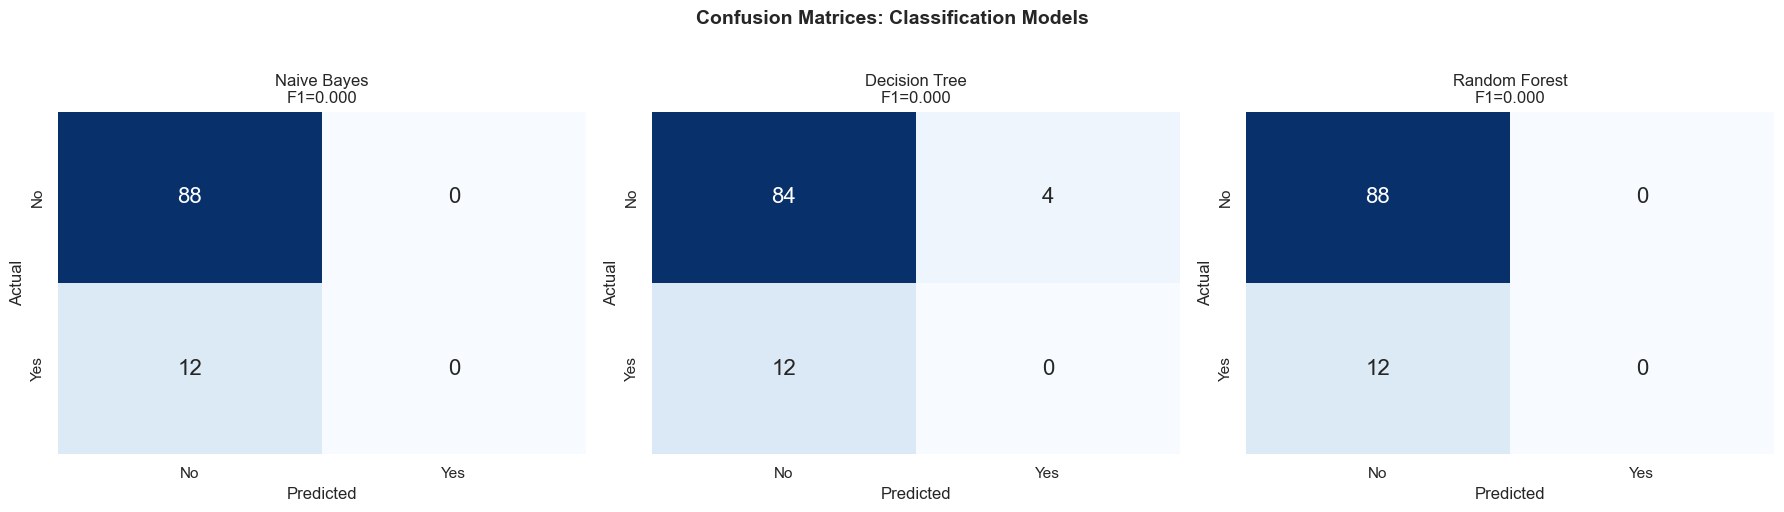

Top-left (TN) and bottom-right (TP) = correct predictions.
Bottom-left (FN) = MISSED leavers — the most dangerous for HR.


In [41]:
# ---- Confusion matrices side by side ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clf_names = ["Naive Bayes", "Decision Tree", "Random Forest"]
clf_preds = [y_pred_nb, y_pred_dt_clf, y_pred_rf_clf]

for ax, name, y_pred in zip(axes, clf_names, clf_preds):
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
                cbar=False, annot_kws={"size": 16})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    f1 = f1_score(y_clf_test, y_pred, zero_division=0)
    ax.set_title(f"{name}\nF1={f1:.3f}")

plt.suptitle("Confusion Matrices: Classification Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Top-left (TN) and bottom-right (TP) = correct predictions.")
print("Bottom-left (FN) = MISSED leavers — the most dangerous for HR.")

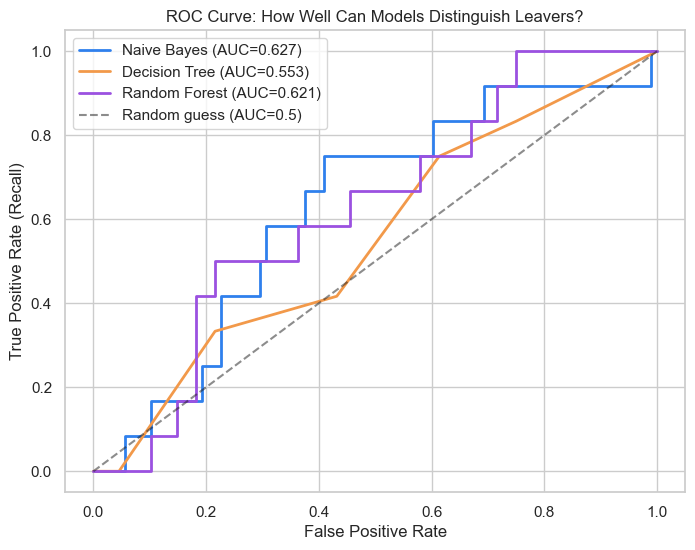

ROC Curve: plots True Positive Rate vs False Positive Rate at all thresholds.
AUC = Area Under Curve. Higher = better at separating classes.
  AUC = 1.0 -> Perfect separation
  AUC = 0.5 -> Random guess (the dashed diagonal)
  AUC < 0.5 -> Worse than random


In [42]:
# ---- ROC Curve ----
plt.figure(figsize=(8, 6))

for name, y_prob, color in zip(clf_names,
                                [y_prob_nb, y_prob_dt_clf, y_prob_rf_clf],
                                ["#2F80ED", "#F2994A", "#9B51E0"]):
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
    auc = roc_auc_score(y_clf_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: How Well Can Models Distinguish Leavers?")
plt.legend()
plt.show()

print("ROC Curve: plots True Positive Rate vs False Positive Rate at all thresholds.")
print("AUC = Area Under Curve. Higher = better at separating classes.")
print("  AUC = 1.0 -> Perfect separation")
print("  AUC = 0.5 -> Random guess (the dashed diagonal)")
print("  AUC < 0.5 -> Worse than random")

In [43]:
# ---- Detailed classification report for best model ----
best_clf_idx = clf_results["F1 Score"].idxmax()
best_clf_name = clf_results.loc[best_clf_idx, "Model"]
best_clf_preds = clf_preds[best_clf_idx]

print(f"Detailed Classification Report: {best_clf_name}")
print("=" * 55)
print(classification_report(y_clf_test, best_clf_preds,
                            target_names=["No (Stay)", "Yes (Leave)"]))

Detailed Classification Report: Naive Bayes
              precision    recall  f1-score   support

   No (Stay)       0.88      1.00      0.94        88
 Yes (Leave)       0.00      0.00      0.00        12

    accuracy                           0.88       100
   macro avg       0.44      0.50      0.47       100
weighted avg       0.77      0.88      0.82       100



### --- PAUSE: Classification Evaluation Discussion ---

**Key insights:**

1. **Accuracy can be misleading** with imbalanced data. Always check Precision, Recall, and F1.

2. **Precision vs Recall trade-off:**
   - High Precision, Low Recall = "When I predict someone will leave, I'm usually right — but I miss many leavers"
   - High Recall, Low Precision = "I catch most leavers — but I also raise many false alarms"
   - F1 balances both

3. **For attrition, we prioritize Recall** — it's better to flag someone who doesn't leave (false alarm) than to miss someone who does (costly surprise).

4. **ROC-AUC** is threshold-independent — it measures how well the model RANKS employees by risk, regardless of where we draw the Yes/No line.

5. **Class imbalance** makes classification harder. The minority class (leavers) has fewer examples to learn from. Techniques like oversampling (SMOTE), undersampling, or class weights can help.

---
# STAGE 12: Overfitting, Generalization & Cross-Validation

---

### What is Generalization?

A model that works well on **new, unseen data** (not just training data) is said to **generalize** well.

### Underfitting vs Good Fit vs Overfitting

| | Underfitting | Good Fit | Overfitting |
|---|---|---|---|
| **Train score** | Low | Good | Excellent (near perfect) |
| **Test score** | Low | Good | Poor |
| **Problem** | Too simple | Just right | Too complex |
| **Analogy** | Didn't study | Understood concepts | Memorized answers |
| **Fix** | More features, complex model | - | Simpler model, more data, regularization |

### How to detect: Train vs Test gap

```
Train R² = 0.95, Test R² = 0.40  -->  GAP = 0.55  -->  OVERFITTING!
Train R² = 0.70, Test R² = 0.65  -->  GAP = 0.05  -->  Good generalization
```

### Cross-Validation: More reliable evaluation

One train-test split can be lucky or unlucky. **K-Fold Cross-Validation** uses K different splits:

```
Fold 1: [Test ] [Train] [Train] [Train] [Train]
Fold 2: [Train] [Test ] [Train] [Train] [Train]
Fold 3: [Train] [Train] [Test ] [Train] [Train]
Fold 4: [Train] [Train] [Train] [Test ] [Train]
Fold 5: [Train] [Train] [Train] [Train] [Test ]

Final score = average of all 5 folds
```

Every row gets to be in the test set exactly once. Much more reliable than a single split.

In [44]:
# ---- Overfitting demonstration: Decision Tree at different depths ----
print("OVERFITTING DEMO: Decision Tree Regression at Different Depths")
print("=" * 70)
print(f"{'Depth':<8} {'Train R²':<12} {'Test R²':<12} {'Gap':<12} {'Verdict'}")
print("-" * 70)

depths = [2, 3, 5, 8, 12, 20, None]
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_reg_train, y_reg_train)
    tr = r2_score(y_reg_train, dt.predict(X_reg_train))
    te = r2_score(y_reg_test, dt.predict(X_reg_test))
    gap = tr - te
    train_scores.append(tr)
    test_scores.append(te)
    
    if te < 0.3:
        verdict = "Underfitting" if tr < 0.5 else "Overfitting"
    elif gap > 0.15:
        verdict = "OVERFITTING"
    else:
        verdict = "Good"
    
    depth_str = str(depth) if depth else "None (unlimited)"
    print(f"{depth_str:<20} {tr:<12.4f} {te:<12.4f} {gap:<12.4f} {verdict}")

print(f"\nAs depth increases:")
print(f"  - Train R² approaches 1.0 (memorization)")
print(f"  - Test R² improves then DROPS (overfitting)")
print(f"  - The gap widens = classic overfitting signal")

OVERFITTING DEMO: Decision Tree Regression at Different Depths
Depth    Train R²     Test R²      Gap          Verdict
----------------------------------------------------------------------
2                    0.5877       0.4745       0.1132       Good
3                    0.6472       0.5583       0.0890       Good
5                    0.7787       0.5732       0.2055       OVERFITTING
8                    0.9412       0.5148       0.4265       OVERFITTING
12                   0.9995       0.5326       0.4668       OVERFITTING
20                   1.0000       0.5064       0.4936       OVERFITTING
None (unlimited)     1.0000       0.5064       0.4936       OVERFITTING

As depth increases:
  - Train R² approaches 1.0 (memorization)
  - Test R² improves then DROPS (overfitting)
  - The gap widens = classic overfitting signal


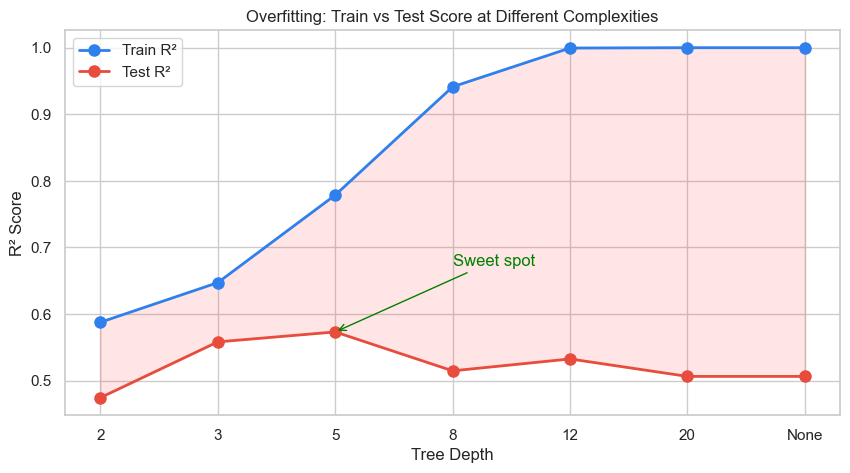

Blue line (Train) keeps going up — the model keeps memorizing.
Red line (Test) peaks then drops — overfitting starts.
The red shaded area = the overfitting gap.
The 'sweet spot' is where Test R² is highest.


In [45]:
# Visualize overfitting
plt.figure(figsize=(10, 5))
depth_labels = [str(d) if d else "None" for d in depths]
plt.plot(depth_labels, train_scores, "o-", color="#2F80ED", linewidth=2, markersize=8, label="Train R²")
plt.plot(depth_labels, test_scores, "o-", color="#E74C3C", linewidth=2, markersize=8, label="Test R²")
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.1, color="red")
plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting: Train vs Test Score at Different Complexities")
plt.legend()
plt.annotate("Sweet spot", xy=(2, test_scores[2]), xytext=(3, test_scores[2] + 0.1),
             arrowprops=dict(arrowstyle="->", color="green"), fontsize=12, color="green")
plt.show()

print("Blue line (Train) keeps going up — the model keeps memorizing.")
print("Red line (Test) peaks then drops — overfitting starts.")
print("The red shaded area = the overfitting gap.")
print("The 'sweet spot' is where Test R² is highest.")

In [46]:
# ---- Cross-Validation ----
from sklearn.model_selection import cross_val_score

print("5-FOLD CROSS-VALIDATION")
print("=" * 70)
print("\nEach model is trained 5 times on different splits.")
print("We report the mean and std of the scores.\n")

# Regression CV
print("--- REGRESSION (metric: R²) ---")
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest (100 trees)": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
}

for name, model in reg_models.items():
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring="r2")
    print(f"  {name:30s}  R² = {scores.mean():.4f} +/- {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

# Classification CV
print(f"\n--- CLASSIFICATION (metric: F1) ---")
clf_models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree (depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest (100 trees)": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
}

for name, model in clf_models.items():
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring="f1")
    print(f"  {name:30s}  F1 = {scores.mean():.4f} +/- {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

print(f"\nLower std = more consistent model (stable across different data splits).")
print(f"Cross-validation gives a more honest estimate than a single train-test split.")

5-FOLD CROSS-VALIDATION

Each model is trained 5 times on different splits.
We report the mean and std of the scores.

--- REGRESSION (metric: R²) ---
  Linear Regression               R² = 0.8113 +/- 0.0207  (folds: 0.825, 0.797, 0.835, 0.822, 0.778)
  Decision Tree (depth=5)         R² = 0.5686 +/- 0.0648  (folds: 0.597, 0.582, 0.654, 0.553, 0.457)


  Random Forest (100 trees)       R² = 0.6992 +/- 0.0289  (folds: 0.716, 0.687, 0.746, 0.682, 0.664)

--- CLASSIFICATION (metric: F1) ---
  Naive Bayes                     F1 = 0.0267 +/- 0.0533  (folds: 0.000, 0.000, 0.133, 0.000, 0.000)
  Decision Tree (depth=5)         F1 = 0.0222 +/- 0.0444  (folds: 0.111, 0.000, 0.000, 0.000, 0.000)


  Random Forest (100 trees)       F1 = 0.0000 +/- 0.0000  (folds: 0.000, 0.000, 0.000, 0.000, 0.000)

Lower std = more consistent model (stable across different data splits).
Cross-validation gives a more honest estimate than a single train-test split.


### --- PAUSE: Generalization Discussion ---

**Key takeaways:**

1. **Overfitting = memorization.** High train score + low test score = danger.
   - Fix: reduce model complexity (lower max_depth), get more data, or use ensemble (Random Forest)

2. **Underfitting = too simple.** Both train and test scores are low.
   - Fix: add features, use more complex model

3. **The sweet spot** is where test performance is maximized — not where train performance is maximized.

4. **Cross-validation** gives a more reliable estimate:
   - Single split: might be lucky or unlucky
   - 5-fold CV: tests on ALL data, averages 5 results
   - Low std across folds = model is stable

5. **Random Forest naturally reduces overfitting** because averaging many trees cancels out individual tree errors.

6. **Always report both train AND test scores** — the gap tells you about generalization.

---
# STAGE 13: Model Comparison & Final Selection

---

### How to choose the best model

| Criteria | Consider |
|---|---|
| **Performance** | Which has the best metric on test data? |
| **Generalization** | Small train-test gap? |
| **Stability** | Low CV standard deviation? |
| **Interpretability** | Can you explain it to stakeholders? |
| **Simplicity** | Is a simpler model almost as good? |

In [47]:
# ---- Final Regression Comparison with Train-Test Gap ----
print("FINAL REGRESSION COMPARISON")
print("=" * 75)

reg_final = []
for name, model, y_pred in [("Linear Regression", lr, y_pred_lr),
                             ("Decision Tree", dt_reg, y_pred_dt),
                             ("Random Forest", rf_reg, y_pred_rf)]:
    train_r2 = r2_score(y_reg_train, model.predict(X_reg_train))
    test_r2 = r2_score(y_reg_test, y_pred)
    mae = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    reg_final.append({
        "Model": name, "Train R²": round(train_r2, 4), "Test R²": round(test_r2, 4),
        "Gap": round(train_r2 - test_r2, 4), "MAE ($)": round(mae, 0), "RMSE ($)": round(rmse, 0),
    })

reg_final_df = pd.DataFrame(reg_final)
print(reg_final_df.to_string(index=False))
print("=" * 75)

FINAL REGRESSION COMPARISON
            Model  Train R²  Test R²    Gap  MAE ($)  RMSE ($)
Linear Regression    0.8293   0.8115 0.0179   4195.0    5050.0
    Decision Tree    0.7787   0.5732 0.2055   6255.0    7599.0
    Random Forest    0.9272   0.7092 0.2180   5136.0    6272.0


In [48]:
# ---- Final Classification Comparison with Train-Test Gap ----
print("\nFINAL CLASSIFICATION COMPARISON")
print("=" * 85)

clf_final = []
for name, model, y_pred, y_prob in [("Naive Bayes", nb, y_pred_nb, y_prob_nb),
                                     ("Decision Tree", dt_clf, y_pred_dt_clf, y_prob_dt_clf),
                                     ("Random Forest", rf_clf, y_pred_rf_clf, y_prob_rf_clf)]:
    train_acc = accuracy_score(y_clf_train, model.predict(X_clf_train))
    test_acc = accuracy_score(y_clf_test, y_pred)
    clf_final.append({
        "Model": name,
        "Train Acc": round(train_acc, 4), "Test Acc": round(test_acc, 4),
        "Gap": round(train_acc - test_acc, 4),
        "Precision": round(precision_score(y_clf_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_clf_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_clf_test, y_pred, zero_division=0), 4),
        "AUC": round(roc_auc_score(y_clf_test, y_prob), 4),
    })

clf_final_df = pd.DataFrame(clf_final)
print(clf_final_df.to_string(index=False))
print("=" * 85)


FINAL CLASSIFICATION COMPARISON
        Model  Train Acc  Test Acc     Gap  Precision  Recall  F1    AUC
  Naive Bayes     0.8650      0.88 -0.0150        0.0     0.0 0.0 0.6269
Decision Tree     0.8975      0.84  0.0575        0.0     0.0 0.0 0.5526
Random Forest     0.8925      0.88  0.0125        0.0     0.0 0.0 0.6212


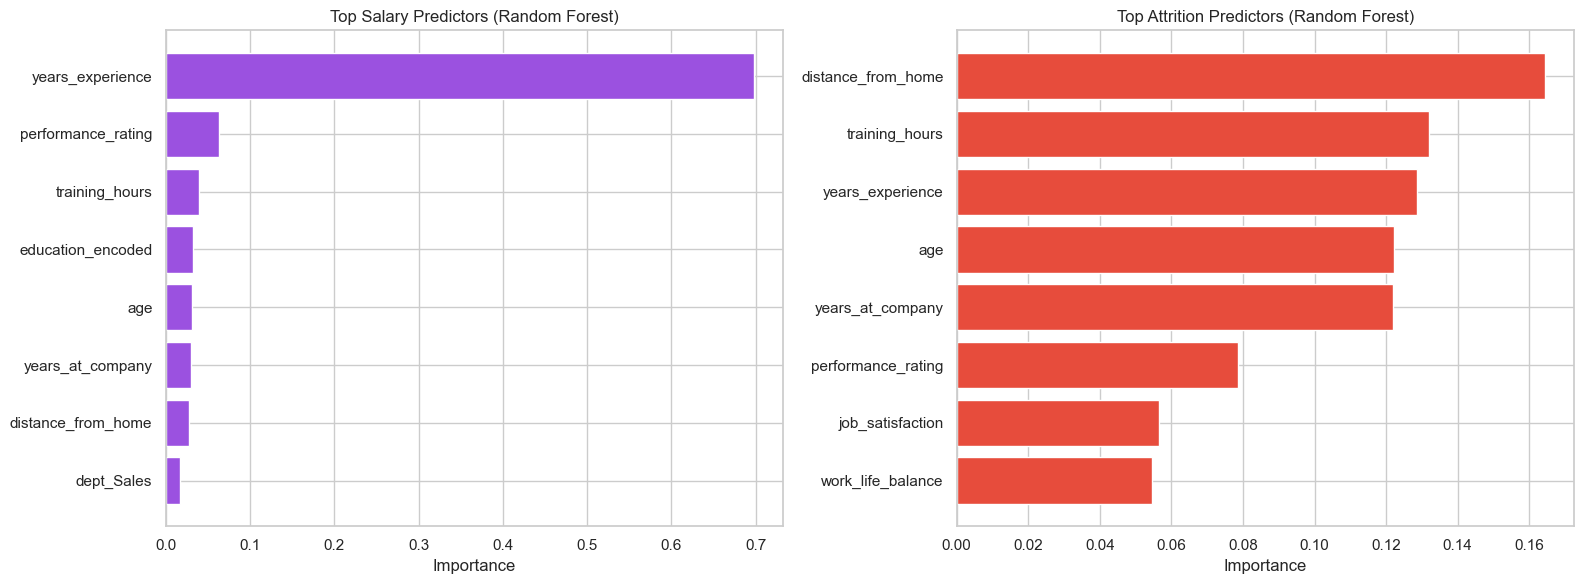

Different targets = different important features.
Salary is driven by experience and performance.
Attrition is driven by satisfaction and work-life balance.


In [49]:
# ---- Visual: Feature Importance Comparison ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression: Random Forest importance
top_reg = rf_imp.head(8)
axes[0].barh(top_reg["feature"], top_reg["importance"], color="#9B51E0")
axes[0].set_xlabel("Importance")
axes[0].set_title("Top Salary Predictors (Random Forest)")
axes[0].invert_yaxis()

# Classification: Random Forest importance
top_clf = rf_clf_imp.head(8)
axes[1].barh(top_clf["feature"], top_clf["importance"], color="#E74C3C")
axes[1].set_xlabel("Importance")
axes[1].set_title("Top Attrition Predictors (Random Forest)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Different targets = different important features.")
print("Salary is driven by experience and performance.")
print("Attrition is driven by satisfaction and work-life balance.")

### --- PAUSE: Model Selection Discussion ---

**Decision framework:**

For **Salary Prediction (Regression):**
- Pick the model with highest Test R² and lowest GAP
- Random Forest typically wins on performance
- Linear Regression is more interpretable (coefficients)
- If performance is close, prefer the simpler model

For **Attrition Prediction (Classification):**
- F1 and Recall matter more than accuracy (imbalanced data)
- ROC-AUC gives overall ranking ability
- Consider the business cost of FN (missed leavers) vs FP (false alarms)

**There is no single 'best' model — it depends on what the business values most.**

---
# STAGE 14: Predict on New Employees & Business Communication

---

### The final goal: use the model on NEW data

Everything we've done — cleaning, EDA, preprocessing, training, evaluating — leads to this moment: **making predictions on data the model has never seen.**

In [50]:
# ---- Create new employee data ----
# Must have the EXACT same columns as reg_features / clf_features
# One-hot columns: dept_Hr, dept_Marketing, dept_Sales, dept_Support
# (Engineering is the dropped first category — all zeros means Engineering)

new_employees = pd.DataFrame({
    "name": ["Alice", "Bob", "Carol"],
    "scenario": ["Senior, happy, Engineering", "Junior, unhappy, overtime", "Mid-level, average"],
    "age": [42, 25, 33],
    "years_experience": [18, 2, 8],
    "years_at_company": [10, 1, 4],
    "distance_from_home": [8, 35, 15],
    "performance_rating": [4, 3, 3],
    "job_satisfaction": [5, 1, 3],
    "work_life_balance": [4, 2, 3],
    "training_hours": [30, 10, 20],
    "gender_encoded": [0, 1, 0],
    "overtime_encoded": [0, 1, 0],
    "education_encoded": [3, 2, 3],  # Masters, Bachelors, Masters
    # Department one-hot: Alice=Engineering (all 0), Bob=Sales, Carol=HR
    "dept_Hr": [0, 0, 1],
    "dept_Marketing": [0, 0, 0],
    "dept_Sales": [0, 1, 0],
    "dept_Support": [0, 0, 0],
})

print("New employees to predict:")
print(new_employees[["name", "scenario"]].to_string(index=False))

New employees to predict:
 name                   scenario
Alice Senior, happy, Engineering
  Bob  Junior, unhappy, overtime
Carol         Mid-level, average


In [51]:
# ---- Predict salary and attrition ----
X_new = new_employees[reg_features]

# Salary prediction (using Random Forest)
salary_pred = rf_reg.predict(X_new)

# Attrition prediction (using Random Forest)
attrition_pred = rf_clf.predict(X_new)
attrition_prob = rf_clf.predict_proba(X_new)[:, 1]

# Results
prediction_report = pd.DataFrame({
    "Employee": new_employees["name"],
    "Scenario": new_employees["scenario"],
    "Predicted Salary ($)": salary_pred.round(0).astype(int),
    "Attrition Risk": ["Yes" if p == 1 else "No" for p in attrition_pred],
    "Attrition Probability": (attrition_prob * 100).round(1),
})

print("\nPREDICTIONS FOR NEW EMPLOYEES")
print("=" * 85)
print(prediction_report.to_string(index=False))
print("=" * 85)


PREDICTIONS FOR NEW EMPLOYEES
Employee                   Scenario  Predicted Salary ($) Attrition Risk  Attrition Probability
   Alice Senior, happy, Engineering                 81469             No                   11.5
     Bob  Junior, unhappy, overtime                 44911             No                   25.9
   Carol         Mid-level, average                 56415             No                    8.9


In [52]:
# ---- Final Business Report ----
best_reg = reg_final_df.loc[reg_final_df["Test R²"].idxmax()]
best_clf = clf_final_df.loc[clf_final_df["F1"].idxmax()]

report = f"""
{'='*65}
   COMPLETE ML PROJECT REPORT: EMPLOYEE PERFORMANCE & ATTRITION
{'='*65}

DATASET: {len(df)} employees | {len(reg_features)} features
SPLIT:   80% training / 20% testing

--- SALARY PREDICTION (REGRESSION) ---
Best Model:  {best_reg['Model']}
  Test R²:   {best_reg['Test R²']:.4f} (explains {best_reg['Test R²']*100:.1f}% of salary variation)
  MAE:       ${best_reg['MAE ($)']:,.0f} (average prediction error)
  RMSE:      ${best_reg['RMSE ($)']:,.0f}
  Train-Test Gap: {best_reg['Gap']:.4f} ({'healthy' if best_reg['Gap'] < 0.1 else 'some overfitting'})

Top Salary Drivers:
{chr(10).join(f'  {i+1}. {row["feature"]:25s} (importance: {row["importance"]:.3f})' for i, (_, row) in enumerate(rf_imp.head(5).iterrows()))}

--- ATTRITION PREDICTION (CLASSIFICATION) ---
Best Model:  {best_clf['Model']}
  Accuracy:  {best_clf['Test Acc']:.4f}
  Precision: {best_clf['Precision']:.4f} (of predicted leavers, this fraction actually left)
  Recall:    {best_clf['Recall']:.4f} (of actual leavers, we caught this fraction)
  F1 Score:  {best_clf['F1']:.4f}
  ROC-AUC:   {best_clf['AUC']:.4f}

Top Attrition Drivers:
{chr(10).join(f'  {i+1}. {row["feature"]:25s} (importance: {row["importance"]:.3f})' for i, (_, row) in enumerate(rf_clf_imp.head(5).iterrows()))}

--- RECOMMENDATIONS ---
1. Use salary model to benchmark new hire offers within +/- ${best_reg['MAE ($)']:,.0f}
2. Flag employees with >30% attrition probability for retention interventions
3. Focus retention efforts on: low satisfaction, overtime, and long commutes
4. Retrain models quarterly as new employee data becomes available

--- CAUTIONS ---
- This is a synthetic dataset — validate with real company data
- Correlation is not causation (overtime correlates with attrition,
  but reducing overtime alone may not fix retention)
- Models should be monitored for fairness across gender and age groups
- Never use ML predictions as the sole basis for employment decisions
{'='*65}
"""

print(report)


   COMPLETE ML PROJECT REPORT: EMPLOYEE PERFORMANCE & ATTRITION

DATASET: 500 employees | 15 features
SPLIT:   80% training / 20% testing

--- SALARY PREDICTION (REGRESSION) ---
Best Model:  Linear Regression
  Test R²:   0.8115 (explains 81.2% of salary variation)
  MAE:       $4,195 (average prediction error)
  RMSE:      $5,050
  Train-Test Gap: 0.0179 (healthy)

Top Salary Drivers:
  1. years_experience          (importance: 0.697)
  2. performance_rating        (importance: 0.064)
  3. training_hours            (importance: 0.040)
  4. education_encoded         (importance: 0.032)
  5. age                       (importance: 0.031)

--- ATTRITION PREDICTION (CLASSIFICATION) ---
Best Model:  Naive Bayes
  Accuracy:  0.8800
  Precision: 0.0000 (of predicted leavers, this fraction actually left)
  Recall:    0.0000 (of actual leavers, we caught this fraction)
  F1 Score:  0.0000
  ROC-AUC:   0.6269

Top Attrition Drivers:
  1. distance_from_home        (importance: 0.164)
  2. traini

### --- PAUSE: Final Reflections ---

### Complete ML Flow — Everything We Covered

```
STAGE 1:  Problem Understanding     -->  Define the business question
STAGE 2:  Data Inspection           -->  shape, info, describe, isna, duplicated
STAGE 3:  Data Cleaning             -->  Fix missing, duplicates, invalid, text
STAGE 4:  Statistics                 -->  Mean, median, std, correlation, skewness
STAGE 5:  Visualization             -->  Histogram, box, scatter, bar, count
STAGE 6:  Preprocessing             -->  Encoding, scaling, feature engineering
STAGE 7:  ML Setup                  -->  Features vs target, train-test split
STAGE 8:  Regression Models         -->  Linear, Decision Tree, Random Forest
STAGE 9:  Regression Evaluation     -->  MAE, MSE, RMSE, R², residuals
STAGE 10: Classification Models     -->  Naive Bayes, Decision Tree, Random Forest
STAGE 11: Classification Evaluation -->  Confusion matrix, precision, recall, F1, ROC-AUC
STAGE 12: Generalization            -->  Overfitting detection, cross-validation
STAGE 13: Model Comparison          -->  Select best model with evidence
STAGE 14: Prediction & Communication -> Predict on new data, report to stakeholders
```

### The Scikit-learn Pattern (works for ANY model)

```python
# 1. Prepare data
X = df[feature_columns]
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Train
model = AnyModel()
model.fit(X_train, y_train)

# 3. Evaluate
y_pred = model.predict(X_test)
print(metric(y_test, y_pred))
```

### Key Principles

| Principle | Why it matters |
|---|---|
| Start with the business question | Models without purpose are useless |
| Clean before modeling | Garbage in = garbage out |
| Understand before predicting | Statistics & visualization reveal data truths |
| Split before training | Test on unseen data to measure real performance |
| Compare multiple models | No single algorithm is always best |
| Check for overfitting | High train + low test = memorization |
| Use cross-validation | One split can be lucky/unlucky |
| Communicate with evidence | Report metrics, features, and cautions |
| Correlation != causation | Always note this caveat |
| Consider fairness & ethics | ML can amplify biases in data |

---

**End of Complete ML Project**

Same dataset. Both regression and classification. From raw messy data to business recommendations.

Every concept from Day 1 (data inspection, cleaning, statistics, visualization) through Day 2 (regression) and Day 3 (classification) — in one unified flow.